
# Load Dataset
Nama : Fransciska Olivia Putri Warae

NIM : 2802516895

Video Penjelasan : https://drive.google.com/file/d/15iLNiPrKTmqMkn-CzE5ge5xiMXNyOVzG/view?usp=sharing 


video keseluruhan : https://drive.google.com/file/d/1WM8lsn5gnK0iXPB7TgWaSl8GyV5lyqZt/view?usp=sharing

Saya menggunakan Data D Car Plane yang ada di version2

Dataset yang digunakan terdiri dari dua saham sektor teknologi, yaitu:

1.⁠ ⁠IBM (International Business Machines Corporation)
2.⁠ ⁠FB (Facebook Inc.)

Sesuai instruksi soal, hanya kolom Date dan Close yang akan digunakan pada tahap pemodelan. Namun data akan dieksplorasi terlebih dahulu untuk memahami karakteristik data.

In [ ]:
ibm_df = pd.read_csv("IBM.csv")
fb_df = pd.read_csv("FB.csv")

In [ ]:
print("IBM Shape :", ibm_df.shape)
print("FB Shape  :", fb_df.shape)

IBM Shape : (14663, 7)
FB Shape  : (1980, 7)


In [ ]:
display(ibm_df.head())

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,7.713333,7.713333,7.626667,7.626667,0.618153,387200
1,1962-01-03,7.626667,7.693333,7.626667,7.693333,0.623556,288000
2,1962-01-04,7.693333,7.693333,7.613333,7.616667,0.617343,256000
3,1962-01-05,7.606667,7.606667,7.453333,7.466667,0.605185,363200
4,1962-01-08,7.460000,7.460000,7.266667,7.326667,0.593837,544000


In [ ]:
display(fb_df.head())

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200


# POIN A : Data Understanding

In [ ]:
fb_df['Date'] = pd.to_datetime(fb_df['Date'])
fb_df = fb_df.sort_values('Date')

all_dates = pd.date_range(
    start=fb_df['Date'].min(),
    end=fb_df['Date'].max(),
    freq='D'
)

fb_df_full = (
    fb_df.set_index('Date')
      .reindex(all_dates)
      .rename_axis('Date')
      .reset_index()
)

fb_df_full.head(15)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400.0
1,2012-05-19,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-05-20,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700.0
4,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600.0
5,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000.0
6,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200.0
7,2012-05-25,32.900002,32.950001,31.110001,31.910000,31.910000,37149800.0
8,2012-05-26,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-05-27,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ibm_df['Date'] = pd.to_datetime(ibm_df['Date'])
ibm_df = ibm_df.sort_values('Date')

all_dates = pd.date_range(
    start=ibm_df['Date'].min(),
    end=ibm_df['Date'].max(),
    freq='D'
)

ibm_df_full = (
    ibm_df.set_index('Date')
      .reindex(all_dates)
      .rename_axis('Date')
      .reset_index()
)

ibm_df_full.head(15)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,7.713333,7.713333,7.626667,7.626667,0.618153,387200.0
1,1962-01-03,7.626667,7.693333,7.626667,7.693333,0.623556,288000.0
2,1962-01-04,7.693333,7.693333,7.613333,7.616667,0.617343,256000.0
3,1962-01-05,7.606667,7.606667,7.453333,7.466667,0.605185,363200.0
4,1962-01-06,NaN,NaN,NaN,NaN,NaN,NaN
5,1962-01-07,NaN,NaN,NaN,NaN,NaN,NaN
6,1962-01-08,7.460000,7.460000,7.266667,7.326667,0.593837,544000.0
7,1962-01-09,7.360000,7.506667,7.360000,7.413333,0.600862,491200.0
8,1962-01-10,7.426667,7.460000,7.426667,7.426667,0.601942,299200.0
9,1962-01-11,7.446667,7.506667,7.446667,7.506667,0.608427,315200.0


Pada implementasi ini, untuk IBM dan FB diasumsikan bahwa prediksi dilakukan untuk hari perdagangan berikutnya      *(next trading day)*, bukan hari kalender berikutnya. Hal ini karena dataset yang digunakan berasal dari data historis saham yang hanya mencatat aktivitas pada hari perdagangan (trading days), sehingga tidak terdapat data pada akhir pekan maupun hari libur bursa.

Di real life, hari perdagangan saham adalah senin-jumat dan tutup pada hari sabtu-minggu.

Dengan demikian, proses pembentukan sliding window dilakukan berdasarkan urutan data yang tersedia pada dataset. Apabila data terakhir dalam suatu window berada pada hari Jumat, maka target prediksi adalah harga pada hari Senin (atau hari perdagangan berikutnya apabila terdapat hari libur bursa). Oleh karena itu, tidak dilakukan penambahan tanggal maupun interpolasi pada hari tanpa aktivitas perdagangan agar model hanya mempelajari harga saham yang benar-benar terjadi di pasar.

--------------------------

Contoh :
18 Mei 2012 (Jumat)

21 Mei 2012 (Senin)

22 Mei 2012 (Selasa)

23 Mei 2012 (Rabu)

24 Mei 2012 (Kamis)

25 Mei 2012 (Jumat)

29 Mei 2012 (Selasa)

*28 Mei libur Memorial Day*

30 Mei 2012 (Rabu)

31 Mei 2012 (Kamis)

1 Juni 2012 (Jumat)

4 Juni 2012 (Senin)

--------------------------
Prediksi 1

18 Mei (Jumat)

21 Mei (Senin)

22 Mei (Selasa)

23 Mei (Rabu)

24 Mei (Kamis)


digunakaan untuk memprediksi: 25 Mei (Jumat)

--------------------------

Prediksi 2

21 Mei (Senin)

22 Mei (Selasa)

23 Mei (Rabu)

24 Mei (Kamis)

25 Mei (Jumat)


digunakaan untuk memprediksi: 29 Mei (Selasa)


Karena 28 Mei adalah Memorial Day, jadi pasar tutup. Targetnya adalah hari perdagangan berikutnya, yaitu 29 Mei.

--------------------------

Contoh Visualisasi

    18 21 22 23 24 | **25**

       21 22 23 24 25 | **29**

          22 23 24 25 29 | **30**

              23 24 25 29 30 | **31**

                 24 25 29 30 31 | **1 Jun**



### Cek Sekilas

In [ ]:
ibm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14663 entries, 0 to 14662
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       14663 non-null  object 
 1   Open       14663 non-null  float64
 2   High       14663 non-null  float64
 3   Low        14663 non-null  float64
 4   Close      14663 non-null  float64
 5   Adj Close  14663 non-null  float64
 6   Volume     14663 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 802.0+ KB


In [ ]:
ibm_df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,14663.000000,14663.000000,14663.000000,14663.000000,14663.000000,1.466300e+04
mean,60.120629,60.677400,59.593508,60.140033,39.328815,4.864190e+06
std,57.326866,57.789666,56.897399,57.353260,50.095679,4.488682e+06
min,4.080000,4.286667,4.000000,4.080000,0.330787,0.000000e+00
25%,16.109375,16.215625,15.985938,16.110937,1.638967,1.320000e+06
50%,28.687500,28.875000,28.406250,28.656250,7.152684,4.102700e+06
75%,102.260002,103.825001,100.829998,102.311249,68.759914,6.851300e+06
max,215.380005,215.899994,214.300003,215.800003,165.514679,6.944470e+07


In [ ]:
(ibm_df['Volume'] == 0).sum()

np.int64(3)

In [ ]:
ibm_df[ibm_df['Volume'] == 0]

,Date,Open,High,Low,Close,Adj Close,Volume
2939,1973-10-09,16.359375,16.359375,16.359375,16.359375,1.433966,0
3267,1975-01-27,10.179688,10.179688,10.179688,10.179688,0.919282,0
5023,1982-01-08,14.187500,14.187500,14.187500,14.187500,1.738599,0


Ditemukan ada volume perdagangan yang memiliki nilai 0 yang artinya tidak ada saham yang diperdagangkan di hari tersebut. Karena penelitian ini hanya menggunakan variabel Close Price sesuai instruksi soal, nilai volume 0 tsb tidak mempengaruhi proses pemodelan.

## IBM

Bagian ini digunakan untuk memahami struktur dataset IBM, tipe data, jumlah observasi, serta kualitas data sebelum dilakukan preprocessing.

### Missing Value Check

In [ ]:
ibm_df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Tidak ada data yang memiliki missing values jadi bisa lanjut ke proses selanjutnya.

### Duplicate Check

In [ ]:
ibm_df.duplicated().sum()

np.int64(0)

Tidak ada yang memiliki data duplikat sehingga dapat dilanjut ke proses berikutnya

### Time Series Visualization

Visualisasi time series dilakukan untuk memahami pola perubahan harga saham IBM dari waktu ke waktu. Tujuannya utk identifikasi tren atau pola umum yang mungkin dapat dipelajari oleh model LSTM.

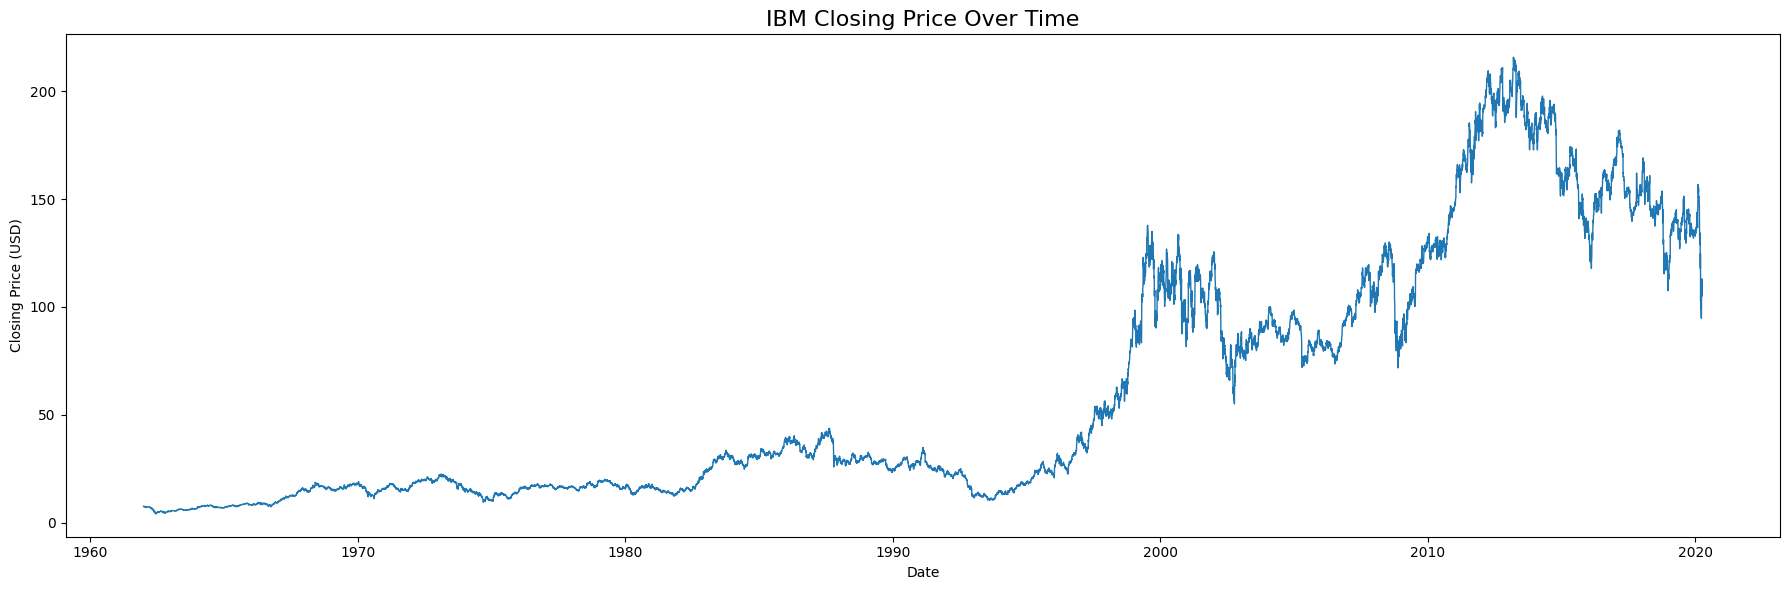

In [ ]:
ibm_ts = ibm_df[['Date', 'Close']].copy()
ibm_ts['Date'] = pd.to_datetime(ibm_ts['Date'])
ibm_ts = ibm_ts.sort_values('Date')

plt.figure(figsize=(18,6))
plt.plot(
    ibm_ts['Date'],
    ibm_ts['Close'],
    linewidth=1
)

plt.title(
    'IBM Closing Price Over Time',
    fontsize=16
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.tight_layout()

plt.show()

Dari grafik diatas, dapat dilihat bahwa data memiliki pola tren jangka panjang yang cenderung meningkat (awal sampai mendekati akhir)

Pada beberapa periode terjadi kenaikan harga yang cukup signifikan, sementara pada periode lainnya terjadi penurunan harga. Hal ini menunjukkan bahwa harga saham dipengaruhi oleh berbagai kondisi pasar sehingga nilainya selalu berubah seiring waktu.

dan bisa dilihat tidak ada pola yang berulang secara konsisten pada periode tertentu.

Bisa disimpulkan : harga saham pada suatu waktu dipengaruhi oleh harga pada waktu-waktu sebelumnya


### Distribution Analysis

digunakan untuk memahami distribusi harga penutupan saham IBM serta melihat apakah distribusi data bersifat simetris atau memiliki skewness tertentu.

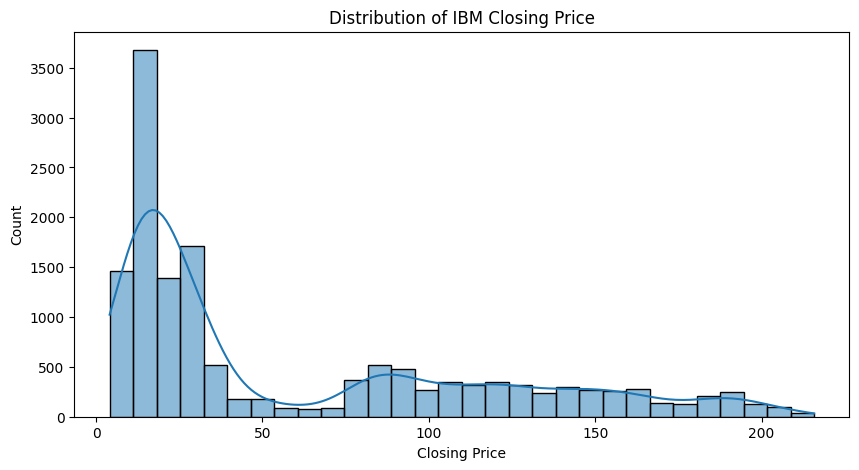

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    ibm_ts['Close'],
    bins=30,
    kde=True
)

plt.title(
    'Distribution of IBM Closing Price'
)

plt.xlabel('Closing Price')

plt.show()

Berdasarkan histogram diatas :

sebagian besar harga penutupan saham IBM berada pada rentang harga yang relatif rendah, yaitu sekitar 5 hingga 40 USD. Namun, terdapat juga sejumlah observasi pada rentang harga yang lebih tinggi, terutama antara 70 sampai 200 USD.




### Outlier Analysis

Boxplot digunakan untuk mengidentifikasi keberadaan nilai ekstrem (outlier) pada harga saham IBM.

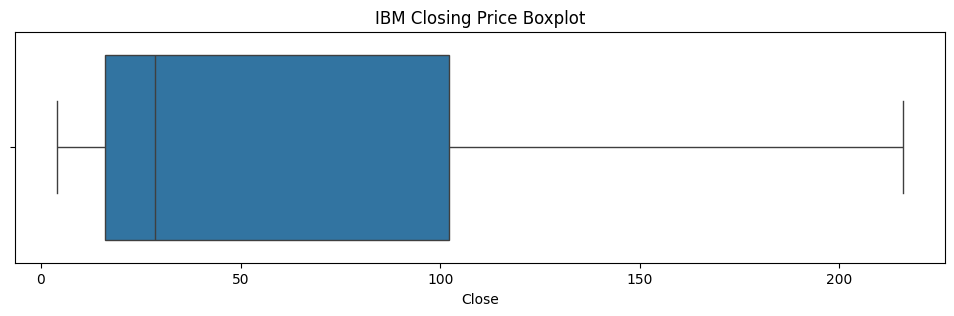

In [ ]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=ibm_ts['Close']
)

plt.title(
    'IBM Closing Price Boxplot'
)

plt.show()

tidak terlihat adanya outlier yang ekstrem berdasarkan IQR.

Median harga saham berada di sekitar 29 USD, yang menunjukkan bahwa setengah dari observasi memiliki harga di bawah nilai tersebut.

whisker pada sisi kanan lebih panjang dibandingkan sisi kiri, yang menunjukkan bahwa terdapat beberapa observasi dengan harga yang relatif tinggi.

### Trend Analysis Using Moving Average

Moving Average digunakan untuk mengurangi fluktuasi jangka pendek dan membantu mengidentifikasi tren jangka panjang pada harga saham IBM.

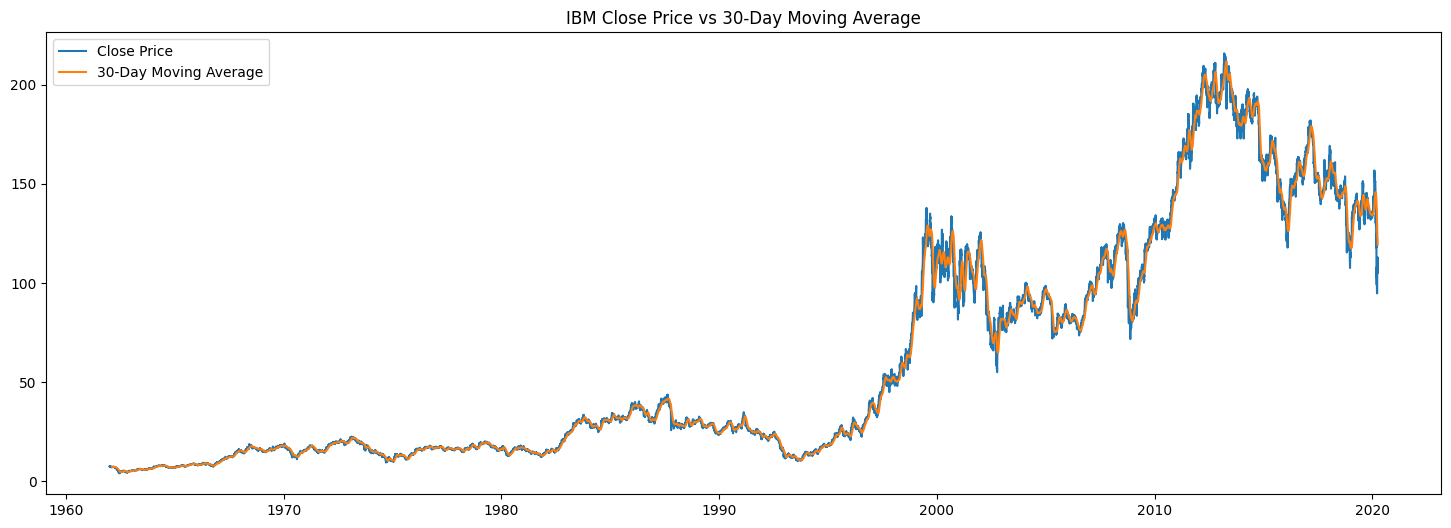

In [ ]:
ibm_ts['MA30'] = (
    ibm_ts['Close']
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(18,6))

plt.plot(
    ibm_ts['Date'],
    ibm_ts['Close'],
    label='Close Price'
)

plt.plot(
    ibm_ts['Date'],
    ibm_ts['MA30'],
    label='30-Day Moving Average'
)

plt.legend()

plt.title(
    'IBM Close Price vs 30-Day Moving Average'
)

plt.show()

garis 30-Day Moving Average mengikuti pola pergerakan harga saham IBM dengan lebih smooth dibandingkan harga penutupan harian.

Penggunaan Moving Average membantu mengurangi fluktuasi jangka pendek sehingga tren umum harga saham dapat terlihat lebih jelas. Bisa dilihat kalau  harga saham mengalami kenaikan atau penurunan yang cukup besar, garis Moving Average tetap mengikuti arah pergerakan tersebut meskipun dengan perubahan yang lebih lambat.

#### Kesimpulan

Berdasarkan hasil eksplorasi data, dataset IBM memiliki kualitas data yang baik karena tidak ditemukan missing value maupun duplicate data.

Visualisasi time series : harga saham IBM mengalami perubahan dari waktu ke waktu dan memiliki pola yang dapat dipelajari dari data historis sebelumnya.

Histogram dan boxplot : menunjukkan bahwa distribusi harga saham tidak simetris dan rentang nilai cukup lebar.

Moving Average : Memperlihatkan tren umum pergerakan harga saham.


## FB

Bagian ini digunakan untuk memahami struktur dataset FB, tipe data, jumlah observasi, serta kualitas data sebelum dilakukan preprocessing.

### Cek Sekilas

In [ ]:
fb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1980 non-null   object 
 1   Open       1980 non-null   float64
 2   High       1980 non-null   float64
 3   Low        1980 non-null   float64
 4   Close      1980 non-null   float64
 5   Adj Close  1980 non-null   float64
 6   Volume     1980 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 108.4+ KB


In [ ]:
fb_df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1.980000e+03
mean,112.285808,113.508752,111.011495,112.312207,112.312207,3.301999e+07
std,58.080987,58.584028,57.575041,58.133793,58.133793,2.959716e+07
min,18.080000,18.270000,17.549999,17.730000,17.730000,5.913100e+06
25%,64.647497,65.575001,63.817501,64.762499,64.762499,1.616085e+07
50%,113.810001,114.654999,112.945000,113.810001,113.810001,2.405750e+07
75%,167.852505,169.492496,166.022499,168.085003,168.085003,3.986862e+07
max,222.570007,224.199997,221.279999,223.229996,223.229996,5.735764e+08


Dibandingkan dengan IBM distribusi harga saham FB relatif lebih seimbang. Bisa dilihat dari nilai median sebesar 113.81 USD berada sangat dekat dengan nilai rata-rata sebesar 112.31 USD.


### Missing Value Check

In [ ]:
fb_df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Tidak ada missing value yang tercatat jadi bisa dilanjut ke proses selanjutnya

### Duplicate Check

In [ ]:
fb_df.duplicated().sum()

np.int64(0)

Tidak ada duplicated value yang tercatat jadi bisa dilanjut ke proses selanjutnya

### Time Series Viualization

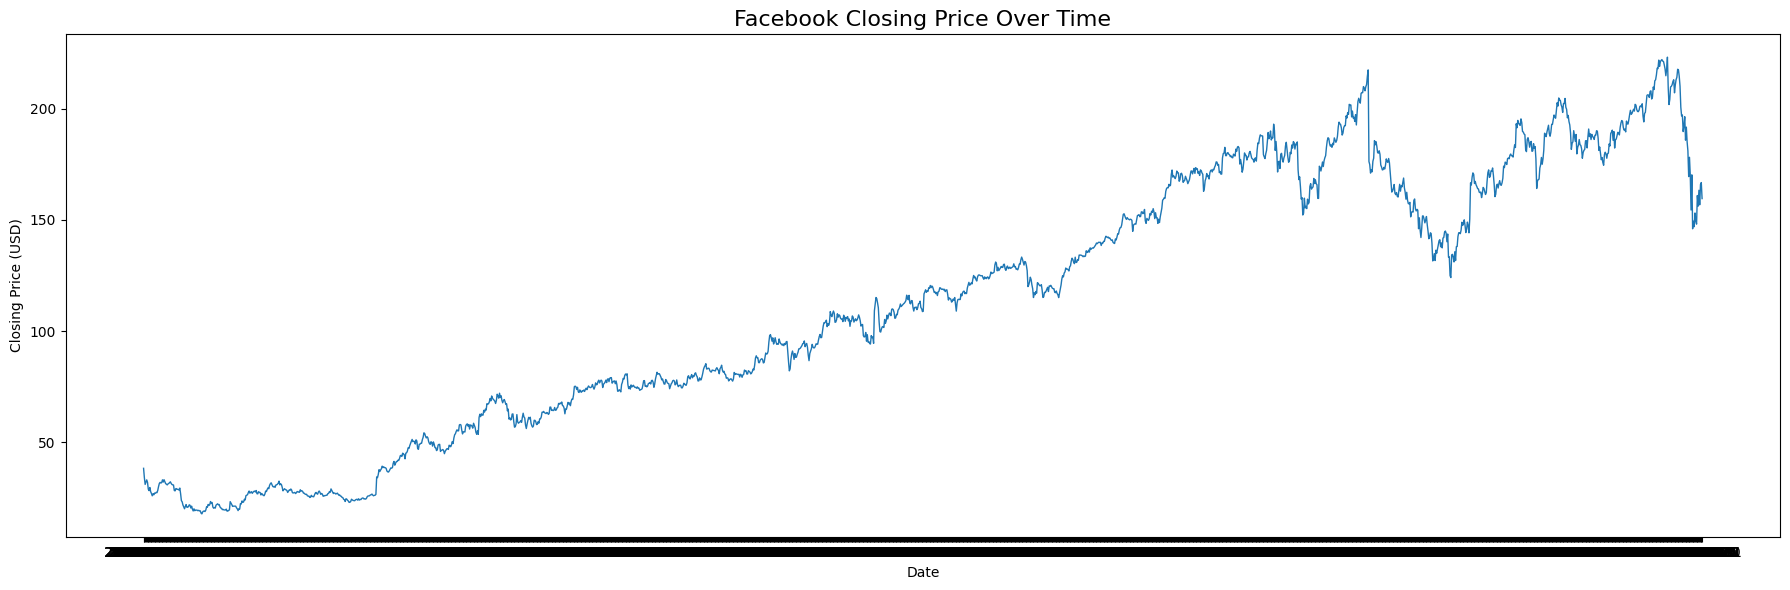

In [ ]:
fb_ts = fb_df[['Date', 'Close']]

plt.figure(figsize=(18,6))

plt.plot(
    fb_ts['Date'],
    fb_ts['Close'],
    linewidth=1
)

plt.title(
    'Facebook Closing Price Over Time',
    fontsize=16
)

plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')

plt.tight_layout()

plt.show()

Berdasarkan grafik diatas close saham Facebook menunjukkan peningkatan selama periode pengamatan. Meskipun terdapat beberapa periode penurunan harga.Tapi secara umum arah grafiknya masih menunjukkan tren naik.

Harga saham mengalami perubahan dari waktu ke waktu dan tidak berada pada nilai yang tetap.




### Distribution Analysis

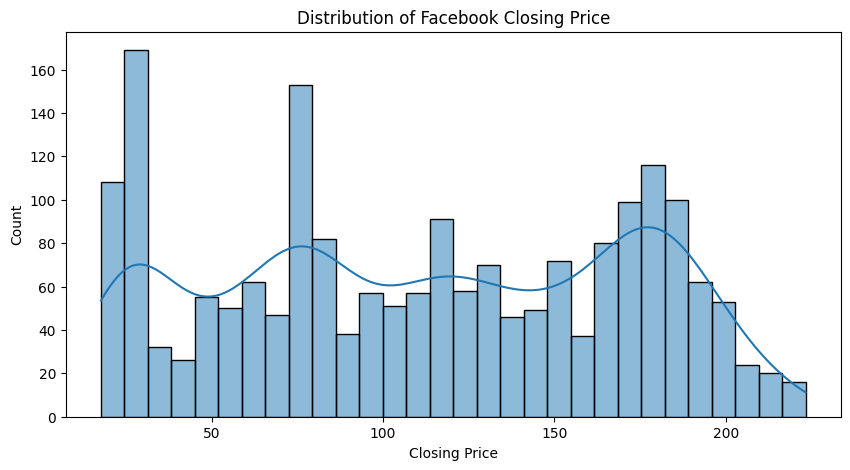

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    fb_ts['Close'],
    bins=30,
    kde=True
)

plt.title(
    'Distribution of Facebook Closing Price'
)

plt.xlabel('Closing Price')

plt.show()

harga penutupan saham Facebook tersebar pada berbagai rentang nilai, mulai dari sekitar 20 USD hingga lebih dari 220 USD.

Dibandingkan dengan IBM, distribusi analisis Facebook lebih merata. Grafik ini juga tidak menunjukkan penumpukkan pada satu rentang harga tertentu. Hal ini sesuai dengan hasil statistik deskriptif yang menunjukkan bahwa nilai rata-rata dan median memiliki nilai yang berdekatan.


### Outlier Analysis

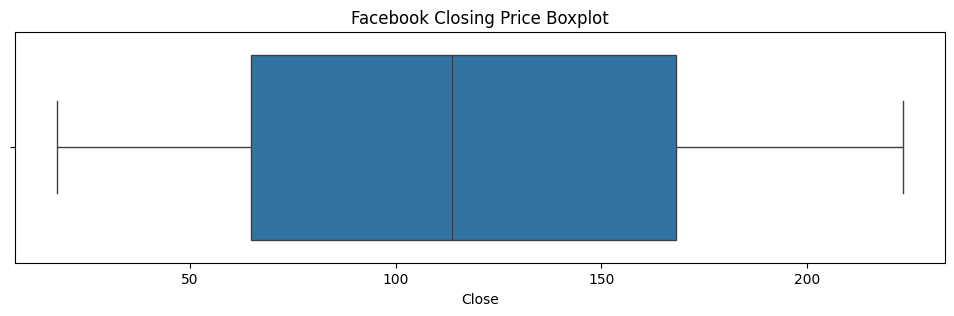

In [ ]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=fb_ts['Close']
)

plt.title(
    'Facebook Closing Price Boxplot'
)

plt.show()

Berdasarkan boxplot di atas, tidak terlihat adanya outlier yang ekstrem berdasarkan metode IQR. Seluruh observasi masih berada dalam rentang whisker sehingga tidak terdapat nilai yang menyimpang secara signifikan dari distribusi data.


Median harga saham FB berada di sekitar 114 USD dan terletak relatif dekat dengan bagian tengah box.

Rentang antara kuartil pertama dan kuartil ketiga cukup lebar, yang menunjukkan adanya variasi harga saham selama periode pengamatan.

### Trend Analysis Using Moving Average

/tmp/ipykernel_1619/2384154775.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fb_ts.loc[:, 'MA30'] = (


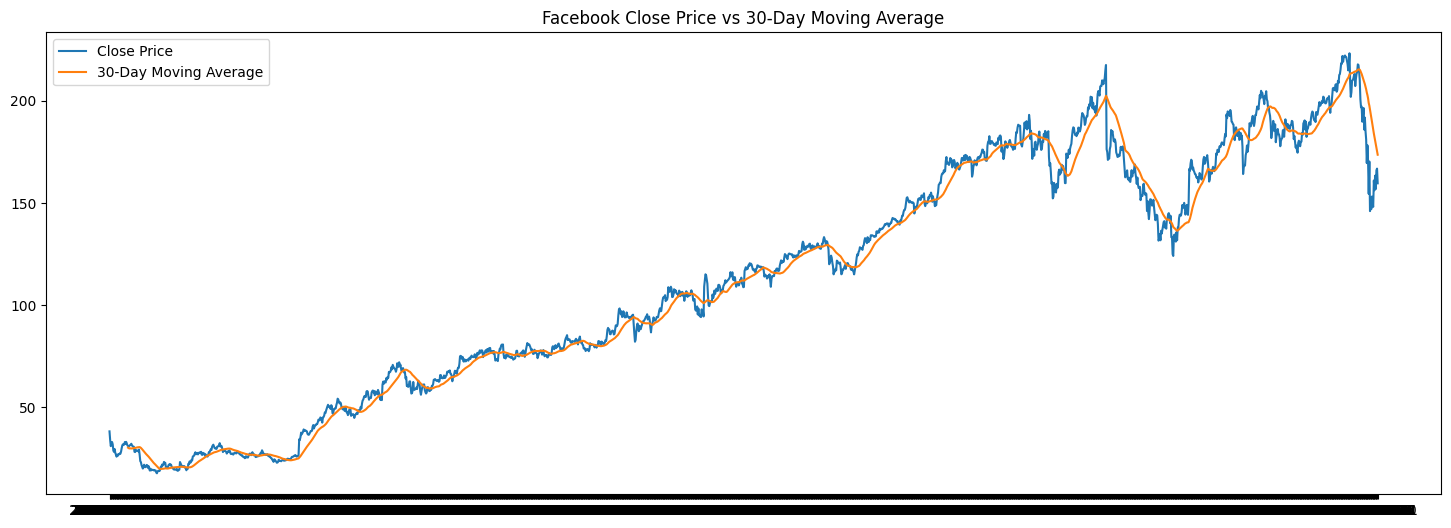

In [ ]:
fb_ts.loc[:, 'MA30'] = (
    fb_ts['Close']
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(18,6))

plt.plot(
    fb_ts['Date'],
    fb_ts['Close'],
    label='Close Price'
)

plt.plot(
    fb_ts['Date'],
    fb_ts['MA30'],
    label='30-Day Moving Average'
)

plt.legend()

plt.title(
    'Facebook Close Price vs 30-Day Moving Average'
)

plt.show()

Dibandingkan harga penutupan harian, garis Moving Average terlihat lebih halus karena telah mengurangi fluktuasi jangka pendek.

Grafik menunjukkan bahwa harga saham Facebook cenderung mengalami peningkatan selama periode pengamatan. Ketika terjadi kenaikan maupun penurunan harga yang cukup signifikan, garis Moving Average tetap mengikuti arah pergerakan tersebut meskipun dengan perubahan yang lebih lambat.

Hasil ini menunjukkan bahwa pergerakan harga saham Facebook memiliki pola historis yang dapat diamati melalui data sebelumnya.

#### Kesimpulan

Berdasarkan hasil eksplorasi data, dataset FB memiliki kualitas data yang baik karena tidak ditemukan missing value maupun duplicate data.

Visualisasi time series : harga saham FB menunjukkan  peningkatan selama periode pengamatan dan memiliki pola yang dapat dipelajari dari data historis sebelumnya.

Histogram dan boxplot : menunjukkan bahwa distribusi harga saham FB relatif lebih seimbang dengan rentang nilai yang cukup lebar.

Moving Average : memperlihatkan tren umum pergerakan harga saham dengan lebih jelas.

### Correlation

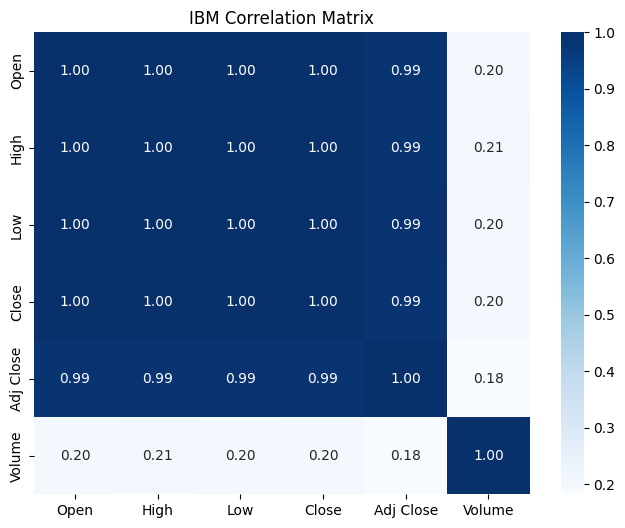

In [ ]:
corr_ibm = ibm_df.drop(columns=['Date']).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_ibm,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('IBM Correlation Matrix')

plt.show()

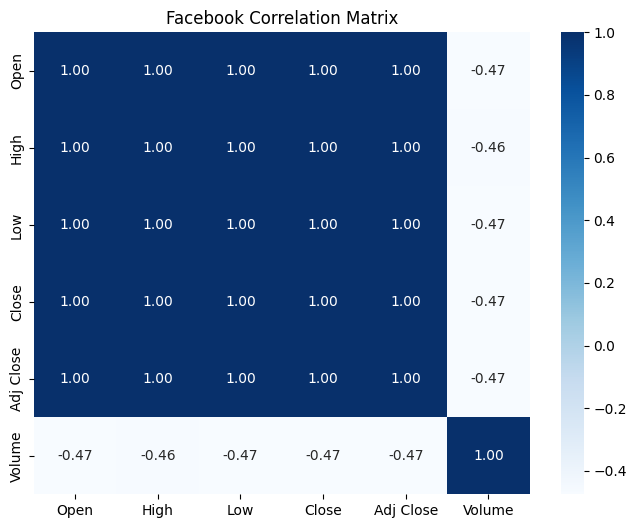

In [ ]:
corr_fb = fb_df.drop(columns=['Date']).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_fb,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Facebook Correlation Matrix')

plt.show()

Berdasarkan instruksi soal, model menggunakan kolom Date dan Close. Selain itu, hasil analisis korelasi menunjukkan bahwa Open, High, Low, dan Adj Close memiliki korelasi yang sangat tinggi terhadap Close, sehingga informasi yang terkandung pada variabel tersebut sudah banyak direpresentasikan oleh nilai Close.

# Time Series Preprocessing

## IBM

### Feature Selection

Sesuai instruksi soal, hanya kolom Date dan Close yang digunakan dalam proses pemodelan. Kolom Date digunakan sebagai indeks waktu dan kolom Close digunakan sebagai target prediksi harga saham.

In [ ]:
ibm_ts = ibm_df[['Date', 'Close']].copy()
ibm_ts['Date'] = pd.to_datetime(ibm_ts['Date'])

ibm_ts = ibm_ts.sort_values('Date')
ibm_ts.head()

,Date,Close
0,1962-01-02,7.626667
1,1962-01-03,7.693333
2,1962-01-04,7.616667
3,1962-01-05,7.466667
4,1962-01-08,7.326667


### Train Test Split

Sesuai instruksi soal, data testing menggunakan satu tahun terakhir dari periode pengamatan. Data sebelum periode tersebut digunakan sebagai data training.

In [ ]:
test_start_date = (
    ibm_ts['Date'].max()
    - pd.DateOffset(years=1)
)

ibm_train = ibm_ts[
    ibm_ts['Date'] < test_start_date
]

ibm_test = ibm_ts[
    ibm_ts['Date'] >= test_start_date
]

print("Train Size :", len(ibm_train))
print("Test Size  :", len(ibm_test))

Train Size : 14409
Test Size  : 254


Ada sebesar 14409 data yang digunakan sebagai data training dan 254 data sebagai data yang akan ditesting.

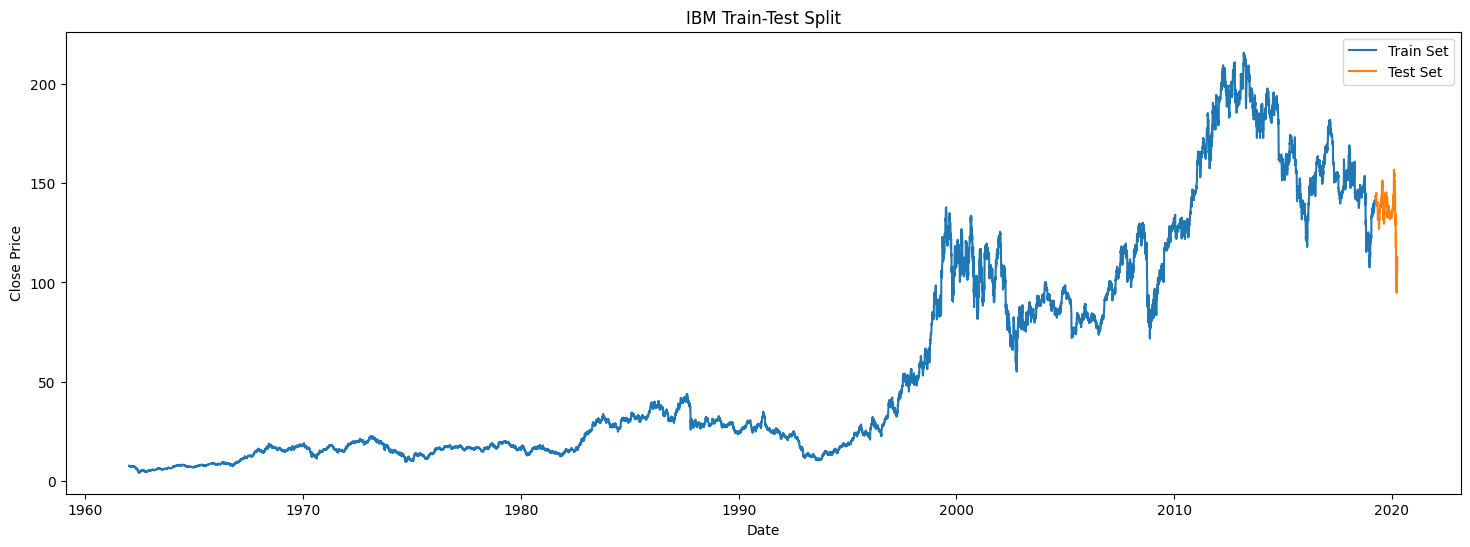

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(
    ibm_train['Date'],
    ibm_train['Close'],
    label='Train Set'
)

plt.plot(
    ibm_test['Date'],
    ibm_test['Close'],
    label='Test Set'
)

plt.title('IBM Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()

plt.show()

In [ ]:
print("Train Size :", len(ibm_train))
print("Test Size :", len(ibm_test))

print("\nTrain Start :", ibm_train['Date'].min())
print("Train End   :", ibm_train['Date'].max())

print("\nTest Start :", ibm_test['Date'].min())
print("Test End   :", ibm_test['Date'].max())

Train Size : 14409
Test Size : 254

Train Start : 1962-01-02 00:00:00
Train End   : 2019-03-29 00:00:00

Test Start : 2019-04-01 00:00:00
Test End   : 2020-04-01 00:00:00


- Data training berisi seluruh data historis sebelum April 2019
- Data testing berisi 1 tahun terakhir (254 hari penjualan)

### Scaling

Normalisasi dilakukan menggunakan MinMaxScaler untuk mengubah rentang nilai harga saham ke interval 0 hingga 1. Tahap ini diperlukan karena model LSTM umumnya bekerja lebih baik pada data yang telah dinormalisasi.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

ibm_scaler = MinMaxScaler()

ibm_train_scaled = ibm_scaler.fit_transform(
    ibm_train[['Close']]
)

ibm_test_scaled = ibm_scaler.transform(
    ibm_test[['Close']]
)

### Window Size = 5 with Horizon = 1

Pada notebook ini saya menggunakan metode *overlapping sliding window* dengan *window size = 5* dan *horizon = 1* (keterangan di soal).

Setiap window bergeser satu hari sehingga sebagian data antar-window saling tumpang tindih (overlap).


In [ ]:
def create_window(
    data,
    window_size=5,
    horizon=1
):

    X = []
    y = []

    for i in range(
        len(data) - window_size - horizon + 1
    ):

        X.append(
            data[i:i+window_size]
        )

        y.append(
            data[
                i+window_size:
                i+window_size+horizon
            ]
        )

    return np.array(X), np.array(y)

In [ ]:
X_ibm_train, y_ibm_train = create_window(
    ibm_train_scaled,
    window_size=5,
    horizon=1
)

X_ibm_test, y_ibm_test = create_window(
    ibm_test_scaled,
    window_size=5,
    horizon=1
)

In [ ]:
print("Input:")
print(X_ibm_train[0].flatten())

print("\nOutput:")
print(y_ibm_train[0].flatten())

Input:
[0.01675168 0.01706657 0.01670445 0.01599597 0.01533472]

Output:
[0.01574407]


In [ ]:
print("X Train Shape :", X_ibm_train.shape)
print("y Train Shape :", y_ibm_train.shape)

print("X Test Shape :", X_ibm_test.shape)
print("y Test Shape :", y_ibm_test.shape)

X Train Shape : (14404, 5, 1)
y Train Shape : (14404, 1, 1)
X Test Shape : (249, 5, 1)
y Test Shape : (249, 1, 1)


Rumus Sliding Window

          Jumlah Sampel = N - Window Size - Horizon + 1

dengan keterangan:

*N* = jumlah data awal

*Window Size* = 5

*Horizon* = 1

        Jumlah Sampel Training = 14409 - 5 - 1 + 1 = 14404
        Jumlah Sampel Test = 254 - 5 - 1 + 1 = 249


- 14404 sampel training
- 249 sampel testing setelah windowing
- setiap sampel punya 5 time steps (window size = 5)
- targetnya 1 nilai (horizon = 1)


### Train-Validation Split

In [ ]:
split_idx_ibm = int(len(X_ibm_train) * 0.9)

X_ibm_train_final = X_ibm_train[:split_idx_ibm]
X_ibm_val = X_ibm_train[split_idx_ibm:]

y_ibm_train_final = y_ibm_train[:split_idx_ibm]
y_ibm_val = y_ibm_train[split_idx_ibm:]

Train = 14404 sampel
Test  = 249 sampel

Train Set

    14404 × 90% = 12963.6 ≈ 12963

Validation Set

    14404 × 10% = 1440.4 ≈ 1441

In [ ]:
print("X IBM Train Shape :", X_ibm_train_final.shape)
print("y IBM Train Shape :", y_ibm_train_final.shape)

print("X IBM Validation Shape :", X_ibm_val.shape)
print("y IBM Validation Shape :", y_ibm_val.shape)

print("X IBM Test Shape :", X_ibm_test.shape)
print("y IBM Test Shape :", y_ibm_test.shape)

X IBM Train Shape : (12963, 5, 1)
y IBM Train Shape : (12963, 1, 1)
X IBM Validation Shape : (1441, 5, 1)
y IBM Validation Shape : (1441, 1, 1)
X IBM Test Shape : (249, 5, 1)
y IBM Test Shape : (249, 1, 1)


## FB

### Feature Selection

In [ ]:
fb_ts = fb_df[['Date', 'Close']].copy()
fb_ts['Date'] = pd.to_datetime(
    fb_ts['Date']
)

fb_ts = fb_ts.sort_values(
    'Date'
)

fb_ts.head()

,Date,Close
0,2012-05-18,38.230000
1,2012-05-21,34.029999
2,2012-05-22,31.000000
3,2012-05-23,32.000000
4,2012-05-24,33.029999


### Train-Test Split

In [ ]:
fb_test_start = (
    fb_ts['Date'].max()
    - pd.DateOffset(years=1)
)

fb_train = fb_ts[
    fb_ts['Date'] < fb_test_start
]

fb_test = fb_ts[
    fb_ts['Date'] >= fb_test_start
]

print("Train Size :", len(fb_train))
print("Test Size :", len(fb_test))

Train Size : 1726
Test Size : 254


In [ ]:
print("Train Start :", fb_train['Date'].min())
print("Train End   :", fb_train['Date'].max())

print()

print("Test Start :", fb_test['Date'].min())
print("Test End   :", fb_test['Date'].max())

Train Start : 2012-05-18 00:00:00
Train End   : 2019-03-29 00:00:00

Test Start : 2019-04-01 00:00:00
Test End   : 2020-04-01 00:00:00


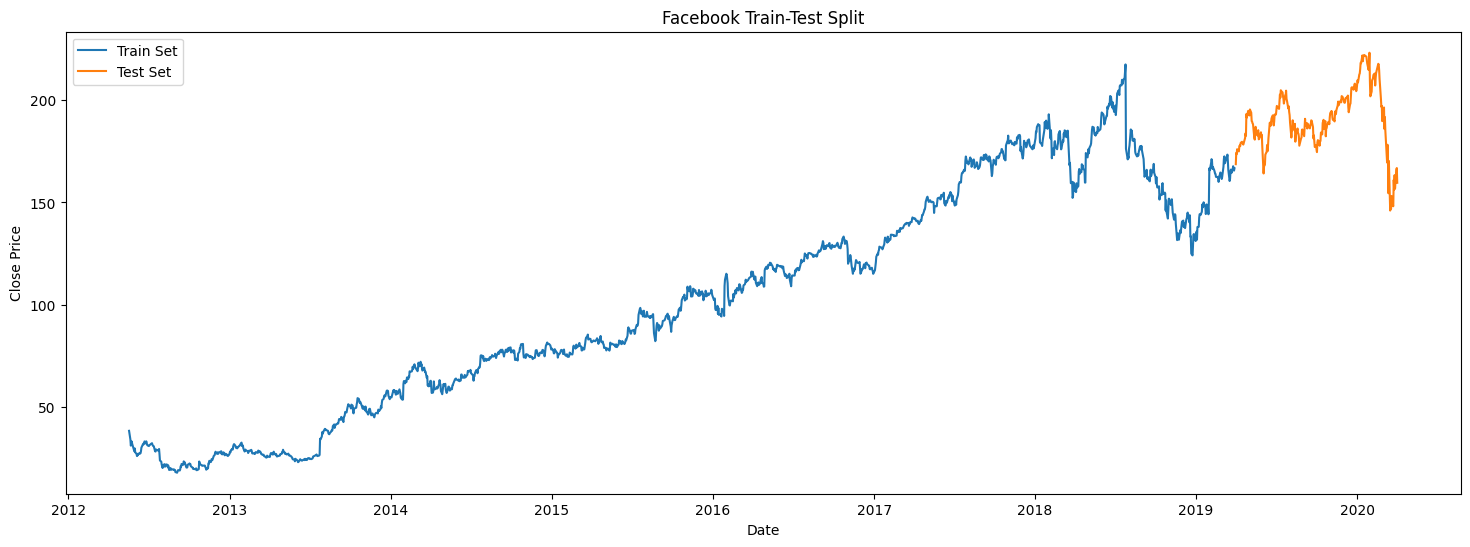

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(
    fb_train['Date'],
    fb_train['Close'],
    label='Train Set'
)

plt.plot(
    fb_test['Date'],
    fb_test['Close'],
    label='Test Set'
)

plt.title('Facebook Train-Test Split')

plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()

plt.show()

Data testing menggunakan satu tahun terakhir dari periode pengamatan, sedangkan data sebelumnya digunakan sebagai data training seperti IBM selanjutnya.

### Scaling

In [ ]:
fb_scaler = MinMaxScaler()

fb_train_scaled = fb_scaler.fit_transform(
    fb_train[['Close']]
)

fb_test_scaled = fb_scaler.transform(
    fb_test[['Close']]
)

In [ ]:
print("Before Scaling")
print(fb_train['Close'].min())
print(fb_train['Close'].max())

print("\nAfter Scaling")
print(fb_train_scaled.min())
print(fb_train_scaled.max())

Before Scaling
17.729999542236328
217.5

After Scaling
0.0
1.0


### Window Size = 5 with Horizon = 1

In [ ]:
X_fb_train, y_fb_train = create_window(
    fb_train_scaled,
    window_size=5,
    horizon=1
)

X_fb_test, y_fb_test = create_window(
    fb_test_scaled,
    window_size=5,
    horizon=1
)

In [ ]:
print("Input:")
print(X_fb_train[0].flatten())

print("\nOutput:")
print(y_fb_train[0].flatten())

Input:
[0.10261801 0.08159383 0.06642639 0.07143215 0.07658807]

Output:
[0.07098163]


    Jumlah Sampel Training = 1726 − 5 − 1 + 1 = 1721

    Jumlah Sampel Test = 254 − 5 − 1 + 1 = 249

•⁠  ⁠1721 sampel training setelah windowing

•⁠  ⁠249 sampel testing setelah windowing

•⁠  ⁠setiap sampel memiliki 5 time steps (window size = 5)

•⁠  ⁠target yang diprediksi sebanyak 1 nilai (horizon = 1)



In [ ]:
print("X Train Shape :", X_fb_train.shape)
print("y Train Shape :", y_fb_train.shape)

print("X Test Shape :", X_fb_test.shape)
print("y Test Shape :", y_fb_test.shape)

X Train Shape : (1721, 5, 1)
y Train Shape : (1721, 1, 1)
X Test Shape : (249, 5, 1)
y Test Shape : (249, 1, 1)


### Train-Validation Split

Jumlah sampel training setelah windowing = 1721

    Train Set = 90% × 1721 ≈ 1548 sampel

    Validation Set = 10% × 1721 ≈ 173 sampel

Sehingga data yang digunakan untuk train model 1548 sampel dan data validasi berjumlah 173 sampel.

In [ ]:
split_idx = int(len(X_fb_train) * 0.9)

X_fb_train_final = X_fb_train[:split_idx]
X_fb_val = X_fb_train[split_idx:]

y_fb_train_final = y_fb_train[:split_idx]
y_fb_val = y_fb_train[split_idx:]

In [ ]:
print("X Train Shape :", X_fb_train_final.shape)
print("y Train Shape :", y_fb_train_final.shape)

print("X Validation Shape :", X_fb_val.shape)
print("y Validation Shape :", y_fb_val.shape)

print("X Test Shape :", X_fb_test.shape)
print("y Test Shape :", y_fb_test.shape)

X Train Shape : (1548, 5, 1)
y Train Shape : (1548, 1, 1)
X Validation Shape : (173, 5, 1)
y Validation Shape : (173, 1, 1)
X Test Shape : (249, 5, 1)
y Test Shape : (249, 1, 1)


# POIN B : Baseline Model

Model baseline dibangun menggunakan satu layer LSTM dengan 50 unit dan fungsi aktivasi ReLU.

Layer output menggunakan Dense dengan 1 neuron untuk memprediksi harga saham pada horizon berikutnya.

    Input Shape (5,1)

          |

    LSTM (50 units, ReLU)

          |

    Dense (1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## IBM

Evaluasi model dilakukan menggunakan metrik MAE dan MAPE.


Model dilatih selama 50 epoch menggunakan data training dan data validation untuk memantau performa model selama proses pelatihan.


Tanpa menggunakan early stop agar agar optimisasi s=maksimal.

### Training

In [ ]:
baseline_ibm = Sequential([
    LSTM(
        units=50,
        activation='relu',
        input_shape=(5,1)
    ),
    Dense(1)
])

baseline_ibm.compile(
    optimizer= 'sgd',
    loss='mse',
    metrics= ['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
baseline_ibm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,453 (40.84 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
history_ibm = baseline_ibm.fit(
    X_ibm_train_final,
    y_ibm_train_final,
    validation_data=(X_ibm_val, y_ibm_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0398 - mae: 0.1520 - val_loss: 0.1466 - val_mae: 0.3768
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0198 - mae: 0.1136 - val_loss: 0.0738 - val_mae: 0.2671
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083 - mae: 0.0725 - val_loss: 0.0253 - val_mae: 0.1557
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0025 - mae: 0.0382 - val_loss: 0.0066 - val_mae: 0.0781
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.0816e-04 - mae: 0.0178 - val_loss: 0.0014 - val_mae: 0.0342
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6538e-04 - mae: 0.0083 - val_loss: 3.8841e-04 - val_mae: 0.0165
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.7129e-05 - mae: 0.0048 - val_loss: 1.9939e-04 - val_mae: 0.0108
Epoch 8/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0692e-05 - mae: 0.0040 - val_loss: 1.6514e-04 - val_mae: 0.0095
Epoch 9/30
406/406 ━━━━━━━━━

### Training Loss VS Validation Loss

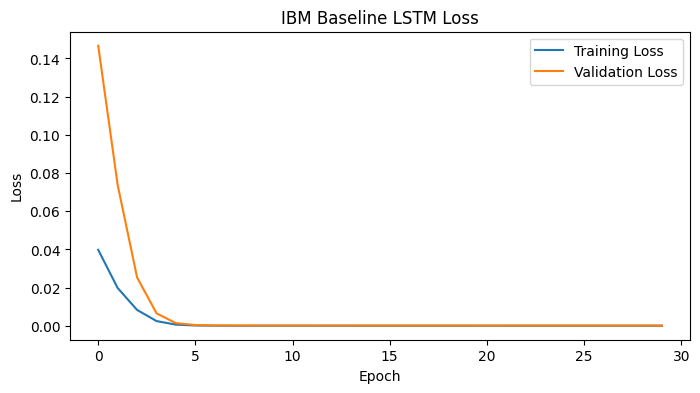

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    history_ibm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_ibm.history['val_loss'],
    label='Validation Loss'
)

plt.title('IBM Baseline LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training loss dan validation loss turun dengan cepat hingga sekitar epoch ke-5, lalu cenderung stabil pada nilai yang rendah. Validation loss mencapai nilai terbaik pada epoch ke-5, menunjukkan bahwa model sudah mampu mempelajari pola data dengan baik. Meskipun validation loss sedikit lebih tinggi daripada training loss, perbedaannya masih kecil sehingga hanya mengindikasikan overfitting ringan.

### Overfitting Check by Calculating Gap Ratio

In [ ]:
print("Final Training Loss :", history_ibm.history['loss'][-1])
print("Final Validation Loss :", history_ibm.history['val_loss'][-1])

print("Gap Ratio :", history_ibm.history['val_loss'][-1] /
                   history_ibm.history['loss'][-1])

Final Training Loss : 4.873263605986722e-05
Final Validation Loss : 0.00014613910752814263
Gap Ratio : 2.998793403020785


Nilai training loss sebesar 0,000049 dan validation loss sebesar 0,000146 menghasilkan gap ratio sebesar 2,99. Berarti ada overfitting ringan karena performa pada data training lebih baik dibandingkan data validasi. Namun, karena kedua nilai loss masih sangat rendah, model tetap mampu melakukan generalisasi dengan cukup baik.


### Test Set Prediction

In [ ]:
y_pred_ibm = baseline_ibm.predict(X_ibm_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


In [ ]:
y_pred_ibm_inv = ibm_scaler.inverse_transform(y_pred_ibm)

y_test_ibm_inv = ibm_scaler.inverse_transform(
    y_ibm_test.reshape(-1,1)
)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_ibm_inv,
        y_pred_ibm_inv
    )
)

mae = mean_absolute_error(
    y_test_ibm_inv,
    y_pred_ibm_inv
)

mape = mean_absolute_percentage_error(
    y_test_ibm_inv,
    y_pred_ibm_inv
)

print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)

RMSE : 3.5801425912719163
MAE  : 2.3322459454517284
MAPE : 0.01795057922805009


Nilai error yang relatif rendah menunjukkan bahwa model mampu memprediksi harga saham IBM dengan cukup akurat, dengan rata-rata kesalahan hanya sekitar 1,80% dari nilai aktual.


### Actual vs Prediction

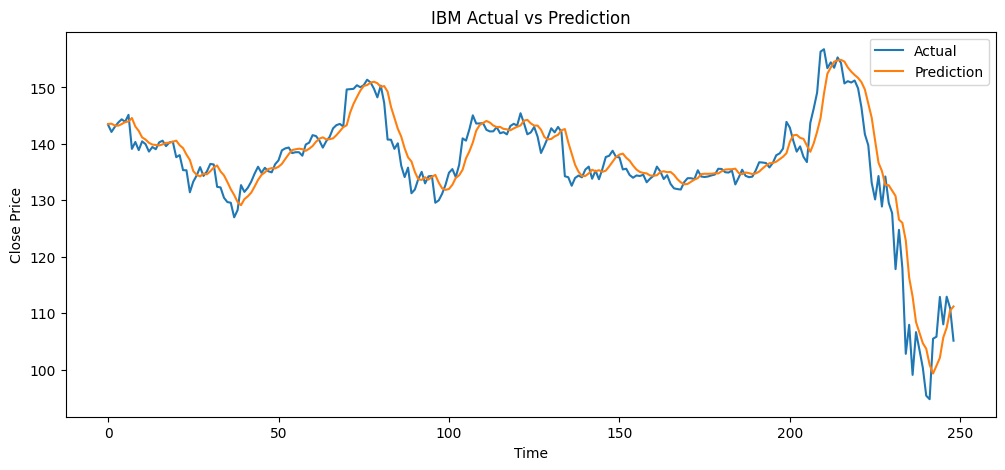

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_ibm_inv,
    label='Actual'
)

plt.plot(
    y_pred_ibm_inv,
    label='Prediction'
)

plt.title('IBM Actual vs Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()

plt.show()

Grafik menunjukkan bahwa hasil prediksi mampu mengikuti pola pergerakan harga saham IBM dengan cukup baik. Garis prediksi terlihat dekat dengan garis aktual pada sebagian besar periode, meskipun terdapat sedikit perbedaan saat terjadi perubahan harga yang cukup tajam. Secara keseluruhan, model berhasil menangkap tren pergerakan harga saham dengan baik.

In [ ]:
print(y_test_ibm_inv[:10])

print(y_pred_ibm_inv[:10])

[[143.38999939]
 [142.11000061]
 [143.02000427]
 [143.77999878]
 [144.3500061 ]
 [143.8999939 ]
 [145.13999939]
 [139.11000061]
 [140.33000183]
 [138.88999939]]
[[143.52116]
 [143.57161]
 [143.24118]
 [143.22081]
 [143.5049 ]
 [143.8509 ]
 [143.96983]
 [144.57483]
 [143.08263]
 [142.29045]]


Model baseline IBM menghasilkan performa prediksi yang baik pada data testing (MAPE 2.79%, MAE 1.96), namun terdapat indikasi **overfitting** karena validation loss lebih besar dibanding training loss dengan gap ratio sekitar 3.1.



## FB

### Training

In [ ]:
baseline_fb = Sequential([
    LSTM(
        units=50,
        activation='relu',
        input_shape=(5,1)
    ),
    Dense(1)
])

baseline_fb.compile(
    optimizer='sgd',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
baseline_fb.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,453 (40.84 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
history_fb = baseline_fb.fit(
    X_fb_train_final,
    y_fb_train_final,
    validation_data=(X_fb_val, y_fb_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.1167 - mae: 0.2673 - val_loss: 0.1529 - val_mae: 0.3836
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0544 - mae: 0.1910 - val_loss: 0.0854 - val_mae: 0.2833
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0455 - mae: 0.1801 - val_loss: 0.0669 - val_mae: 0.2497
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0405 - mae: 0.1711 - val_loss: 0.0588 - val_mae: 0.2339
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0362 - mae: 0.1618 - val_loss: 0.0525 - val_mae: 0.2209
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0322 - mae: 0.1527 - val_loss: 0.0471 - val_mae: 0.2090
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0283 - mae: 0.1429 - val_loss: 0.0398 - val_mae: 0.1916
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0245 - mae: 0.1328 - val_loss: 0.0361 - val_mae: 0.1824
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0212 - mae:

### Training Loss VS Validation Loss

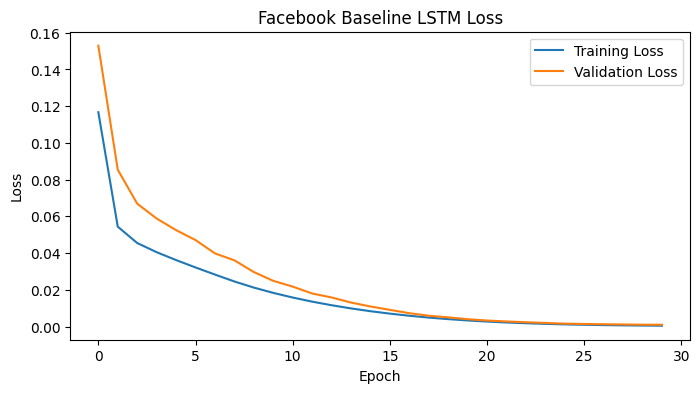

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    history_fb.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_fb.history['val_loss'],
    label='Validation Loss'
)

plt.title('Facebook Baseline LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training loss dan validation loss sama-sama turun secara konsisten selama proses pelatihan. Penurunan terbesar terjadi pada epoch 1–10,

Validation loss terendah dicapai pada epoch ke-29 dengan nilai sekitar 0,00096, menunjukkan bahwa model masih terus belajar hingga akhir training tanpa tanda overfitting yang signifikan.


### Overfitting Check by Calculating Gap Ratio

In [ ]:
print(
    "Final Training Loss :",
    history_fb.history['loss'][-1]
)

print(
    "Final Validation Loss :",
    history_fb.history['val_loss'][-1]
)

print(
    "Gap Ratio :",
    history_fb.history['val_loss'][-1] /
    history_fb.history['loss'][-1]
)

Final Training Loss : 0.0004446826933417469
Final Validation Loss : 0.0009561849292367697
Gap Ratio : 2.150263420532815


Nilai training loss sebesar 0,00044 dan validation loss sebesar 0,00096 menghasilkan gap ratio 2,15. Hal ini menunjukkan adanya indikasi overfitting ringan karena performa pada data training lebih baik dibandingkan data validasi. Namun, karena kedua nilai loss masih sangat rendah dan selisihnya tidak terlalu besar, model masih mampu melakukan generalisasi dengan cukup baik.


### Test Set Prediction

In [ ]:
y_pred_fb = baseline_fb.predict(
    X_fb_test
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


In [ ]:
y_pred_fb_inv = fb_scaler.inverse_transform(
    y_pred_fb
)

y_test_fb_inv = fb_scaler.inverse_transform(
    y_fb_test.reshape(-1,1)
)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

rmse_fb = np.sqrt(
    mean_squared_error(
        y_test_fb_inv,
        y_pred_fb_inv
    )
)

mae_fb = mean_absolute_error(
    y_test_fb_inv,
    y_pred_fb_inv
)

mape_fb = mean_absolute_percentage_error(
    y_test_fb_inv,
    y_pred_fb_inv
)

print("RMSE :", rmse_fb)
print("MAE  :", mae_fb)
print("MAPE :", mape_fb)

RMSE : 8.276898575703209
MAE  : 7.2496421844605
MAPE : 0.037506547158496086


 Nilai ini menunjukkan bahwa model mampu memprediksi harga saham Facebook dengan cukup baik, meskipun tingkat kesalahannya masih lebih tinggi dibandingkan model IBM. Rata-rata selisih prediksi terhadap harga aktual berada di sekitar 3,75%, sehingga akurasi model masih tergolong cukup baik untuk menangkap tren pergerakan harga saham.


### Actual vs Prediction

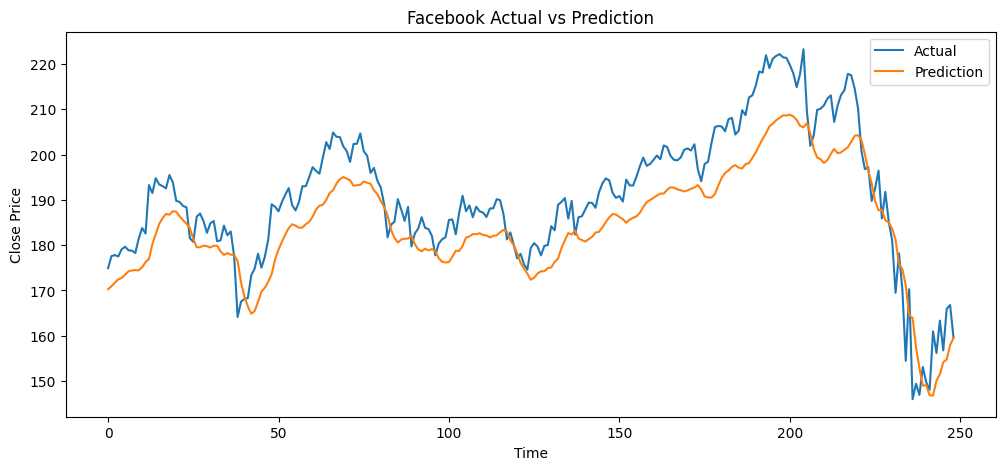

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_fb_inv,
    label='Actual'
)

plt.plot(
    y_pred_fb_inv,
    label='Prediction'
)

plt.title(
    'Facebook Actual vs Prediction'
)

plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()

plt.show()

Grafik menunjukkan bahwa garis prediksi berhasil mengikuti arah pergerakan harga saham Facebook secara umum. Namun, pada beberapa bagian, terutama saat terjadi kenaikan dan penurunan yang cukup tajam, garis prediksi terlihat lebih halus dan sedikit tertinggal dari data aktual.

# POIN C : Modifikasi Arsitektur

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

## IBM - V1

Model Modified IBM dibuat dengan menambahkan satu layer LSTM sehingga model bisa menangkap pola pergerakan harga saham yang lebih kompleks dibanding model baseline.

Aktivasi ReLU diganti menjadi tanh karena lebih cocok untuk data time series dan membuat proses training lebih stabil.

Dense layer ditambahkan untuk membantu mengolah hasil ekstraksi fitur sebelum menghasilkan prediksi.

Optimizer juga diubah dari SGD menjadi Adam agar proses train lebih cepat dan efisien.

Ditambahkan Early Stopping untuk mengurangi risiko overfitting selama training.

### Training

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

mod_ibm = Sequential([

    LSTM(
        units=64,
        activation='tanh',
        return_sequences=True,
        input_shape=(5,1)
    ),

    LSTM(
        units=32,
        activation='tanh'
    ),

    Dense(
        units=16,
        activation='relu'
    ),

    Dense(1)

])

mod_ibm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
mod_ibm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,573 (349.90 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,716 (233.27 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_mod_ibm = mod_ibm.fit(
    X_ibm_train,
    y_ibm_train,
    validation_data=(X_ibm_val, y_ibm_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5.3809e-05 - mae: 0.0047 - val_loss: 9.1355e-05 - val_mae: 0.0068
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 4.4069e-05 - mae: 0.0041 - val_loss: 1.7240e-04 - val_mae: 0.0105
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 4.6334e-05 - mae: 0.0042 - val_loss: 1.0799e-04 - val_mae: 0.0076
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 4.4987e-05 - mae: 0.0041 - val_loss: 1.2027e-04 - val_mae: 0.0082
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 4.8326e-05 - mae: 0.0044 - val_loss: 8.7242e-05 - val_mae: 0.0065
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 4.8596e-05 - mae: 0.0044 - val_loss: 3.5538e-04 - val_mae: 0.0167
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 4.7033e-05 - mae: 0.0043 - val_loss: 1.2058e-04 - val_mae: 0.0085
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 4.4779e-05 - mae: 0.0041 - val_loss: 9.8533e-05 - val_mae:

### Training Loss vs Validity Loss

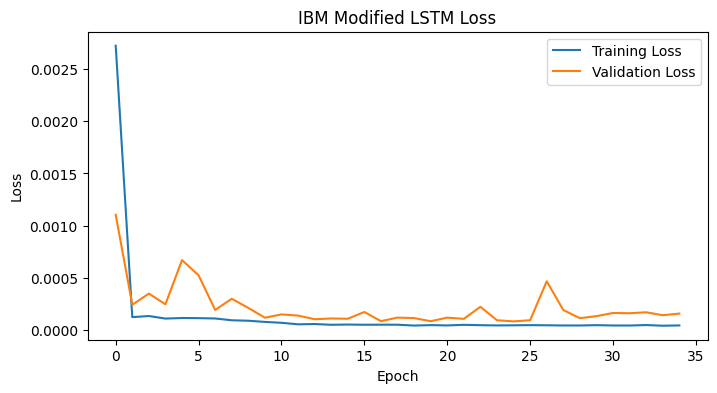

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    history_mod_ibm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mod_ibm.history['val_loss'],
    label='Validation Loss'
)

plt.title('IBM Modified LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training loss turun sangat cepat pada epoch 1–2 dan kemudian stabil di nilai yang sangat rendah. Validation loss terbaik berada di sekitar epoch ke-10, menunjukkan bahwa model sudah mampu mempelajari pola data dengan baik sejak awal proses training.


### Overfitting Check by Caculating gap ratio

In [ ]:
print(
    "Final Training Loss :",
    history_mod_ibm.history['loss'][-1]
)

print(
    "Final Validation Loss :",
    history_mod_ibm.history['val_loss'][-1]
)

print(
    "Gap Ratio :",
    history_mod_ibm.history['val_loss'][-1] /
    history_mod_ibm.history['loss'][-1]
)

Final Training Loss : 4.65402081317734e-05
Final Validation Loss : 0.00015994920977391303
Gap Ratio : 3.436796185376626


gap ratio 3,44 menunjukkan adanya indikasi overfitting ringan karena performa pada data training lebih baik dibandingkan data validasi. Namun, karena kedua nilai loss masih sangat kecil, model tetap memiliki kemampuan mengenali yang baik.


### Test Set Prediction

In [ ]:
y_pred_mod_ibm = mod_ibm.predict(
    X_ibm_test
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [ ]:
y_pred_mod_ibm_inv = ibm_scaler.inverse_transform(y_pred_mod_ibm)

rmse_mod_ibm = np.sqrt(
    mean_squared_error(
        y_test_ibm_inv,
        y_pred_mod_ibm_inv
    )
)

mae_mod_ibm = mean_absolute_error(
    y_test_ibm_inv,
    y_pred_mod_ibm_inv
)

mape_mod_ibm = mean_absolute_percentage_error(
    y_test_ibm_inv,
    y_pred_mod_ibm_inv
)

print("RMSE :", rmse_mod_ibm)
print("MAE :", mae_mod_ibm)
print("MAPE :", mape_mod_ibm)

RMSE : 2.705687371274652
MAE : 1.7561797482900352
MAPE : 0.0135409034784995


Model IBM Modified menghasilkan RMSE sebesar 2,71, MAE sebesar 1,76, dan MAPE sebesar 1,35%. Dibandingkan model IBM Baseline, seluruh nilai error mengalami penurunan. Hal ini menunjukkan bahwa modifikasi arsitektur berhasil meningkatkan akurasi prediksi dan membuat hasil prediksi lebih dekat dengan harga saham aktual.


### Actual vs Prediction

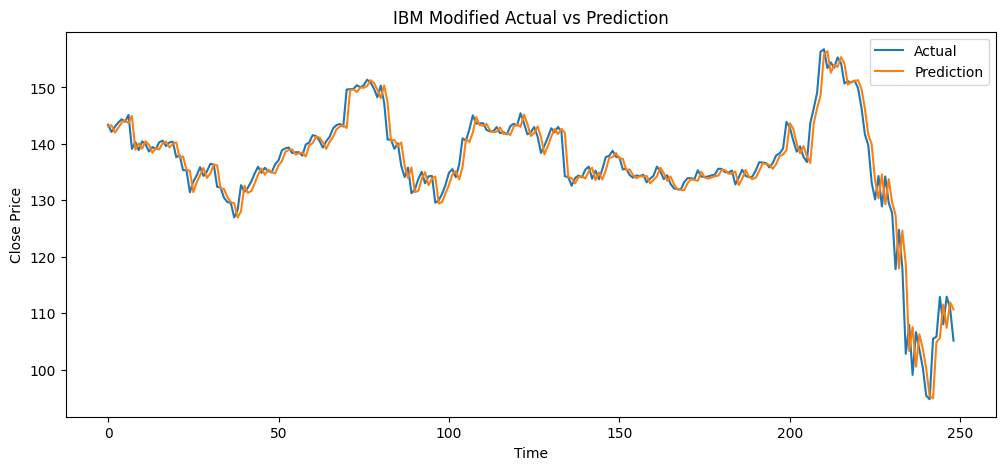

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_ibm_inv,
    label='Actual'
)

plt.plot(
    y_pred_mod_ibm_inv,
    label='Prediction'
)

plt.title(
    'IBM Modified Actual vs Prediction'
)

plt.xlabel('Time')
plt.ylabel('Close Price')

plt.legend()

plt.show()

Grafik menunjukkan bahwa garis prediksi hampir bertumpuk dengan garis aktual di sebagian besar titik. Model mampu mengikuti pola kenaikan dan penurunan harga saham dengan sangat baik

## IBM V2

Model Modified 2 dikembangkan dari Modified 1 dengan menambahkan Dropout sebesar 0,1 setelah layer LSTM pertama.

Dropout berfungsi untuk menonaktifkan sebagian neuron secara acak selama proses training sehingga model tidak terlalu bergantung pada neuron tertentu.

Tujuannya adalah mengurangi risiko overfitting dan meningkatkan kemampuan model dalam melakukan generalisasi pada data yang belum pernah dilihat sebelumnya.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

modified_ibm = Sequential([

    LSTM(
        units=64,
        activation='tanh',
        return_sequences=True,
        input_shape=(5,1)
    ),

    Dropout(0.1),

    LSTM(
        units=32,
        activation='tanh'
    ),

    Dense(
        units=16,
        activation='relu'
    ),

    Dense(1)

])

modified_ibm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
modified_ibm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,573 (349.90 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,716 (233.27 KB)

In [ ]:
history_modified_ibm = modified_ibm.fit(
    X_ibm_train,
    y_ibm_train,
    validation_data=(X_ibm_val, y_ibm_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0022 - mae: 0.0159 - val_loss: 3.9534e-04 - val_mae: 0.0156
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 1.8763e-04 - mae: 0.0084 - val_loss: 2.7901e-04 - val_mae: 0.0129
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.7776e-04 - mae: 0.0084 - val_loss: 5.5279e-04 - val_mae: 0.0196
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 1.6004e-04 - mae: 0.0081 - val_loss: 2.1021e-04 - val_mae: 0.0106
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 1.5858e-04 - mae: 0.0082 - val_loss: 2.1319e-04 - val_mae: 0.0105
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.5032e-04 - mae: 0.0080 - val_loss: 2.4848e-04 - val_mae: 0.0124
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 1.3483e-04 - mae: 0.0076 - val_loss: 1.7736e-04 - val_mae: 0.0097
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.4371e-04 - mae: 0.0080 - val_loss: 4.0318e-04 - val_mae: 0.

### Training Loss VS Validation Loss

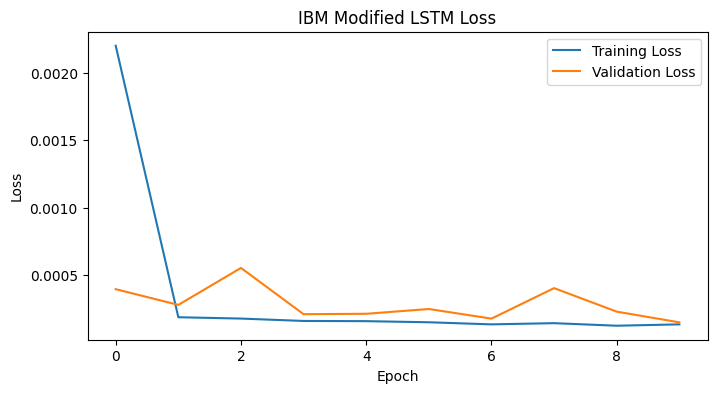

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    history_modified_ibm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_modified_ibm.history['val_loss'],
    label='Validation Loss'
)

plt.title('IBM Modified LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training loss turun cepat dan mulai stabil sejak epoch ke-1. Validation loss sempat berfluktuasi, tetapi tetap berada pada nilai yang rendah. Validation loss terendah terjadi sekitar epoch ke-3, menunjukkan model sudah belajar pola data dengan baik tanpa peningkatan error yang signifikan.


### Overfitting Check by Calculating Ratio Gap

In [ ]:
print(
    "Final Training Loss :",
    history_modified_ibm.history['loss'][-1]
)

print(
    "Final Validation Loss :",
    history_modified_ibm.history['val_loss'][-1]
)

print(
    "Gap Ratio :",
    history_modified_ibm.history['val_loss'][-1] /
    history_modified_ibm.history['loss'][-1]
)

Final Training Loss : 0.00013475463492795825
Final Validation Loss : 0.0001497867051512003
Gap Ratio : 1.1115514151426287


Training loss sebesar 0.000135 dan validation loss sebesar 0.000150 menghasilkan gap ratio 1.11. Nilai ini jauh lebih kecil dibanding baseline maupun Modified 1, sehingga menunjukkan overfitting berhasil dikurangi dan kemampuan generalisasi model menjadi lebih baik.


### Test Set Prediction

In [ ]:
y_pred_modified_ibm = modified_ibm.predict(
    X_ibm_test
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [ ]:
y_pred_modified_ibm_inv = ibm_scaler.inverse_transform(y_pred_modified_ibm)

rmse_modified_ibm = np.sqrt(
    mean_squared_error(
        y_test_ibm_inv,
        y_pred_modified_ibm_inv
    )
)

mae_modified_ibm = mean_absolute_error(
    y_test_ibm_inv,
    y_pred_modified_ibm_inv
)

mape_modified_ibm = mean_absolute_percentage_error(
    y_test_ibm_inv,
    y_pred_modified_ibm_inv
)

print("RMSE :", rmse_modified_ibm)
print("MAE :", mae_modified_ibm)
print("MAPE :", mape_modified_ibm)

RMSE : 5.383568350854593
MAE : 3.950206618711172
MAPE : 0.030141238503163536


Model menghasilkan RMSE 5.38, MAE 3.95, dan MAPE 3.01%. Nilai ini menunjukkan prediksi masih cukup baik, meskipun performanya sedikit menurun dibanding Modified 1.



### Actual VS Prediction

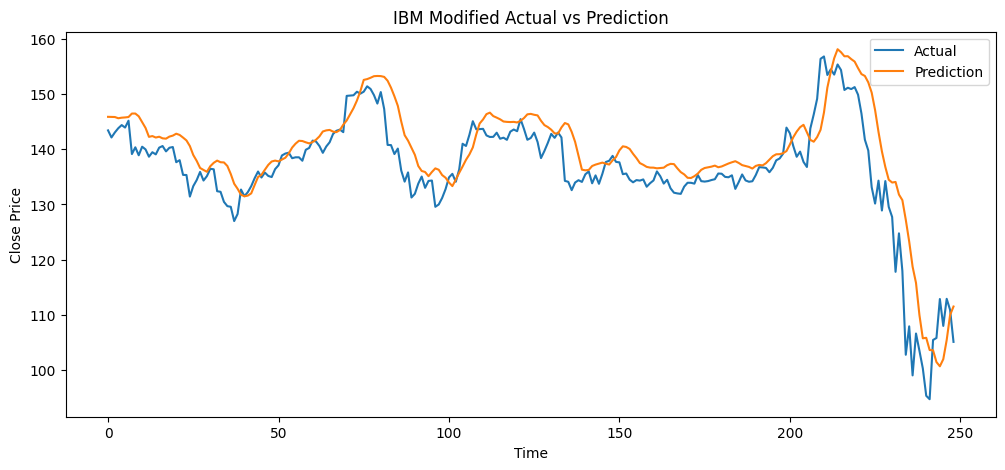

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_ibm_inv,
    label='Actual'
)

plt.plot(
    y_pred_modified_ibm_inv,
    label='Prediction'
)

plt.title(
    'IBM Modified Actual vs Prediction'
)

plt.xlabel('Time')
plt.ylabel('Close Price')

plt.legend()

plt.show()

Garis prediksi sudah mengikuti pola data aktual, tetapi masih terlihat lebih halus dan kurang mampu mengikuti perubahan harga yang tajam. Hal ini menunjukkan efek Dropout yang membuat model lebih stabil, namun sedikit mengurangi ketepatan prediksi.

### Kesimpulan Modified IBM

Secara keseluruhan, Modified 1 memberikan hasil prediksi terbaik dengan error paling rendah, sedangkan Modified 2 memiliki kemampuan generalisasi yang lebih baik karena gap ratio paling kecil. Untuk prediksi harga saham IBM, Modified 1 dipilih sebagai model terbaik karena menghasilkan akurasi tertinggi.

## FB V1

Facebook Modified dibuat dengan menambahkan satu layer LSTM sehingga model dapat menangkap pola pergerakan harga saham yang lebih kompleks dibandingkan model baseline.

Aktivasi ReLU pada layer LSTM diganti menjadi tanh karena lebih sesuai untuk data time series dan membantu proses pembelajaran menjadi lebih stabil.

Ditambahkan Dense layer untuk mengolah hasil fitur sebelum menghasilkan prediksi.

Optimizer juga diubah dari SGD menjadi Adam agar proses training lebih cepat dan mampu mencapai konvergensi yang lebih baik.

### Training

In [ ]:
from tensorflow.keras.optimizers import Adam

mod_fb = Sequential([

    LSTM(
        units=64,
        activation='tanh',
        return_sequences=True,
        input_shape=(5,1)
    ),


    LSTM(
        units=32,
        activation='tanh'
    ),

    Dense(
        units=16,
        activation='relu'
    ),

    Dense(1)

])

mod_fb.compile(
    optimizer="adam",
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
mod_fb.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,573 (349.90 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,716 (233.27 KB)

In [ ]:
history_mod_fb = mod_fb.fit(
    X_fb_train_final,
    y_fb_train_final,
    validation_data=(X_fb_val, y_fb_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.1470e-04 - mae: 0.0104 - val_loss: 0.0014 - val_mae: 0.0255
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0045e-04 - mae: 0.0101 - val_loss: 0.0012 - val_mae: 0.0232
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9762e-04 - mae: 0.0099 - val_loss: 0.0011 - val_mae: 0.0221
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9821e-04 - mae: 0.0099 - val_loss: 0.0011 - val_mae: 0.0217
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.2019e-04 - mae: 0.0104 - val_loss: 0.0014 - val_mae: 0.0253
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0100e-04 - mae: 0.0100 - val_loss: 0.0011 - val_mae: 0.0215
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.8751e-04 - mae: 0.0094 - val_loss: 0.0010 - val_mae: 0.0215
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0363e-04 - mae: 0.0103 - val_loss: 0.0010 - val_mae: 0.0220
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 

### Training Loss vs Validation Loss

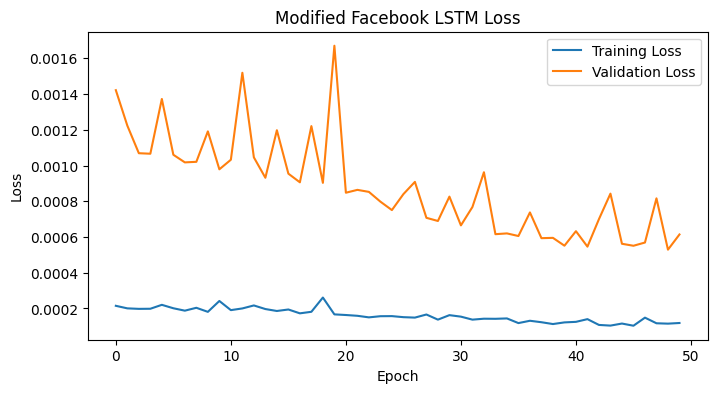

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    history_mod_fb.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mod_fb.history['val_loss'],
    label='Validation Loss'
)

plt.title('Modified Facebook LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training loss turun sangat cepat pada awal pelatihan dan kemudian stabil di sekitar 0.0001–0.0003. Validation loss masih berfluktuasi di beberapa epoch, tetapi secara umum menunjukkan tren menurun dan mencapai nilai terendah sekitar epoch ke-49.


### Overfitting Check by Gap Ratio

In [ ]:
print(
    "Final Training Loss :",
    history_mod_fb.history['loss'][-1]
)

print(
    "Final Validation Loss :",
    history_mod_fb.history['val_loss'][-1]
)

print(
    "Gap Ratio :",
    history_mod_fb.history['val_loss'][-1] /
    history_mod_fb.history['loss'][-1]
)

Final Training Loss : 0.00011844930850202218
Final Validation Loss : 0.0006140997866168618
Gap Ratio : 5.1844944844602265


Training loss sebesar 0.000118 dan validation loss sebesar 0.000614 menghasilkan gap ratio 5.18. Nilai ini menunjukkan masih terdapat indikasi overfitting karena performa pada data training lebih baik dibanding data validasi.


### Test Set Prediction

In [ ]:
y_pred_mod_fb = mod_fb.predict(X_fb_test)
y_pred_mod_fb_inv = fb_scaler.inverse_transform(y_pred_mod_fb)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

rmse_mod_fb = np.sqrt(
    mean_squared_error(
        y_test_fb_inv,
        y_pred_mod_fb_inv
    )
)

mae_mod_fb = mean_absolute_error(
    y_test_fb_inv,
    y_pred_mod_fb_inv
)

mape_mod_fb = mean_absolute_percentage_error(
    y_test_fb_inv,
    y_pred_mod_fb_inv
)

print("RMSE :", rmse_mod_fb)
print("MAE :", mae_mod_fb)
print("MAPE :", mape_mod_fb)

RMSE : 5.0112196608979644
MAE : 4.057578948606931
MAPE : 0.021565718325099015


Model menghasilkan RMSE sebesar 5.01, MAE sebesar 4.06, dan MAPE sebesar 2.16%. Nilai ini lebih baik dibanding baseline Facebook, menunjukkan bahwa modifikasi arsitektur berhasil meningkatkan akurasi prediksi.


### Actual VS Prediction

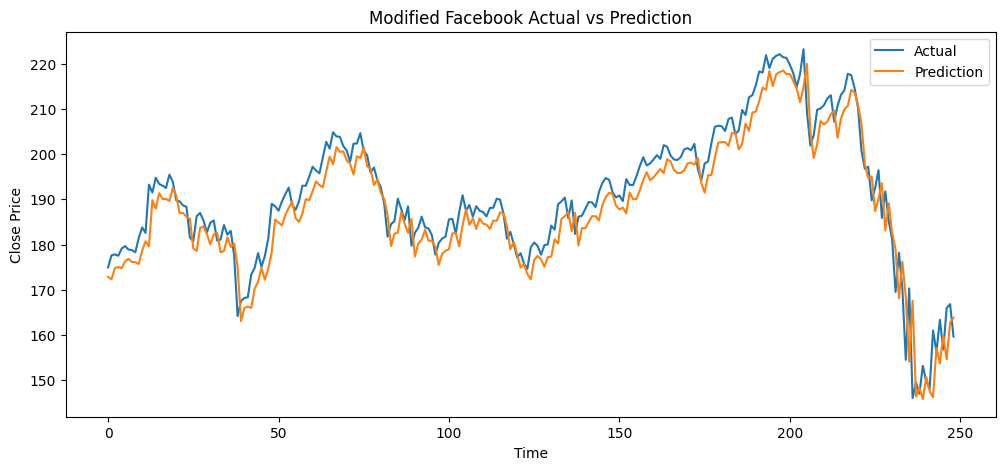

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_fb_inv,
    label='Actual'
)

plt.plot(
    y_pred_mod_fb_inv,
    label='Prediction'
)

plt.title(
    'Modified Facebook Actual vs Prediction'
)

plt.xlabel('Time')
plt.ylabel('Close Price')

plt.legend()

plt.show()

Garis prediksi mampu mengikuti pola pergerakan harga saham Facebook dengan cukup baik dan terlihat lebih dekat dengan data aktual. Sebagian besar kenaikan dan penurunan harga berhasil ditangkap oleh model, meskipun masih terdapat sedikit selisih pada beberapa titik ekstrem.


## FB V2

Disini saya menambahkan nilai droput sebesar 0.1 setelah layer LSTM pertama. Dropout digunakan untuk menonaktifkan sebagian neuron secara acak selama proses training sehingga model tidak terlalu bergantung pada pola tertentu pada data training. Tujuannya adalah mengurangi risiko overfitting dan meningkatkan kemampuan generalisasi model terhadap data baru

In [ ]:
modified_fb = Sequential([

    LSTM(
        units=64,
        activation='tanh',
        return_sequences=True,
        input_shape=(5,1)
    ),

    Dropout(0.1),

    LSTM(
        units=32,
        activation='tanh'
    ),

    Dense(
        units=16,
        activation='relu'
    ),

    Dense(1)

])

modified_fb.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
modified_fb.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_modified_fb = modified_fb.fit(
    X_fb_train_final,
    y_fb_train_final,
    validation_data=(X_fb_val, y_fb_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0270 - mae: 0.0953 - val_loss: 0.0019 - val_mae: 0.0289
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.2436e-04 - mae: 0.0147 - val_loss: 0.0015 - val_mae: 0.0253
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1451e-04 - mae: 0.0146 - val_loss: 0.0020 - val_mae: 0.0310
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6444e-04 - mae: 0.0137 - val_loss: 0.0014 - val_mae: 0.0252
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8194e-04 - mae: 0.0139 - val_loss: 0.0015 - val_mae: 0.0281
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.4562e-04 - mae: 0.0132 - val_loss: 0.0015 - val_mae: 0.0253
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.4877e-04 - mae: 0.0131 - val_loss: 0.0017 - val_mae: 0.0273
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8919e-04 - mae: 0.0142 - val_loss: 0.0017 - val_mae: 0.0279
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 

### Training Loss VS Validation Loss

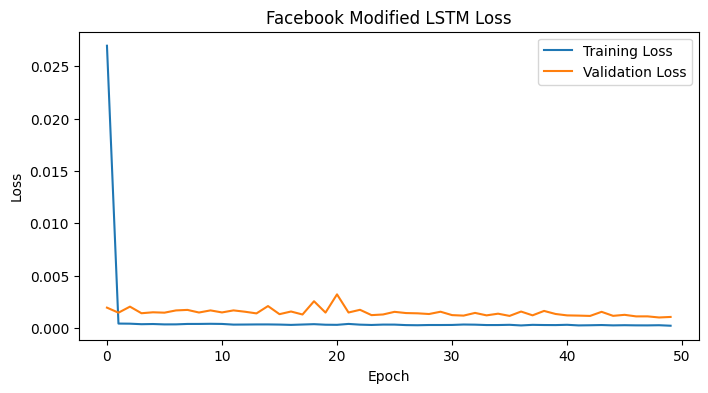

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    history_modified_fb.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_modified_fb.history['val_loss'],
    label='Validation Loss'
)

plt.title('Facebook Modified LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training loss turun sangat cepat pada awal pelatihan dan kemudian stabil pada nilai yang rendah. Validation loss juga cenderung stabil meskipun mengalami sedikit fluktuasi di beberapa epoch. Tidak terlihat peningkatan validation loss yang signifikan hingga akhir pelatihan, menunjukkan model mampu mempelajari pola data dengan cukup baik.

### Overfitting Check by Calculating Gap Ratio

In [ ]:
print(
    "Final Training Loss :",
    history_modified_fb.history['loss'][-1]
)

print(
    "Final Validation Loss :",
    history_modified_fb.history['val_loss'][-1]
)

print(
    "Gap Ratio :",
    history_modified_fb.history['val_loss'][-1] /
    history_modified_fb.history['loss'][-1]
)

Final Training Loss : 0.00038361450424417853
Final Validation Loss : 0.0012739161029458046
Gap Ratio : 3.320823610295326


Training loss sebesar 0.000384 dan validation loss sebesar 0.001274 menghasilkan gap ratio 3.32. Nilai ini lebih rendah dibanding Modified 1 yang memiliki gap ratio sekitar 5.18, sehingga menunjukkan bahwa penambahan Dropout berhasil mengurangi tingkat overfitting dan meningkatkan kemampuan generalisasi model.


### Test Set Prediction

In [ ]:
y_pred_modified_fb = modified_fb.predict(X_fb_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [ ]:
y_pred_modified_fb_inv = fb_scaler.inverse_transform(y_pred_modified_fb)

y_test_fb_inv = fb_scaler.inverse_transform(
    y_fb_test.reshape(-1,1)
)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

rmse_modified_fb = np.sqrt(
    mean_squared_error(
        y_test_fb_inv,
        y_pred_modified_fb_inv
    )
)

mae_modified_fb = mean_absolute_error(
    y_test_fb_inv,
    y_pred_modified_fb_inv
)

mape_modified_fb = mean_absolute_percentage_error(
    y_test_fb_inv,
    y_pred_modified_fb_inv
)

print("RMSE :", rmse_modified_fb)
print("MAE :", mae_modified_fb)
print("MAPE :", mape_modified_fb)

RMSE : 12.523073401226442
MAE : 10.842479966251723
MAPE : 0.05731339758913357


Dibandingkan Modified 1, nilai error meningkat sehingga akurasi prediksi sedikit menurun. Hal ini menunjukkan bahwa regularisasi melalui Dropout membuat model lebih konservatif dalam belajar sehingga mengurangi overfitting, tetapi mengorbankan sebagian ketepatan prediksi.


### Actual vs Prediction

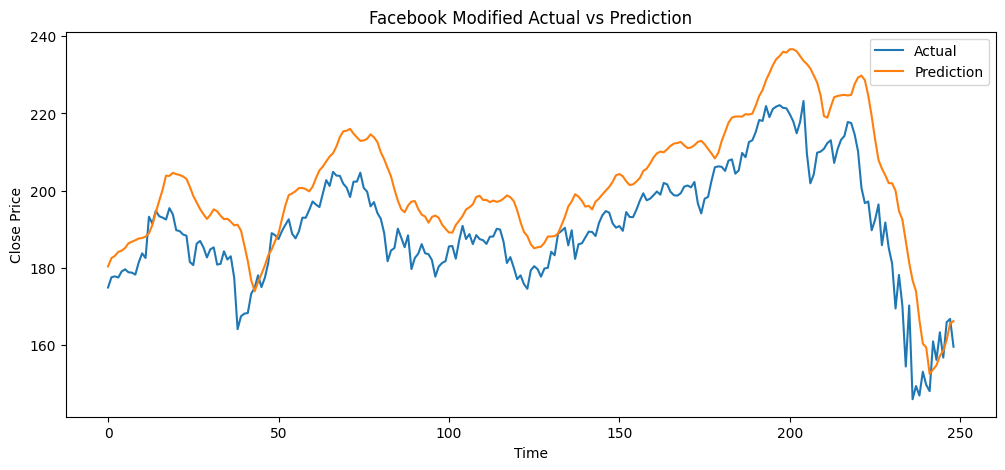

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_fb_inv,
    label='Actual'
)

plt.plot(
    y_pred_modified_fb_inv,
    label='Prediction'
)

plt.title(
    'Facebook Modified Actual vs Prediction'
)

plt.xlabel('Time')
plt.ylabel('Close Price')

plt.legend()

plt.show()

Garis prediksi mampu mengikuti tren pergerakan harga saham secara umum, namun terlihat lebih halus dibanding data aktual. Pada beberapa titik puncak dan penurunan tajam, model masih menunjukkan deviasi yang cukup besar dari nilai aktual. Kondisi ini menunjukkan bahwa Dropout berhasil membuat model lebih stabil, tetapi mengurangi kemampuannya dalam menangkap perubahan harga yang sangat cepat.


### Kesimpulan FB

Berdasarkan hasil evaluasi, Modified 1 memberikan performa terbaik pada prediksi harga saham Facebook dengan RMSE 5.01, MAE 4.06, dan MAPE 2.16%, yang lebih baik dibanding Modified 2. Meskipun Modified 2 berhasil menurunkan gap ratio dari 5.18 menjadi 3.32 melalui penambahan Dropout, peningkatan kemampuan generalisasi tersebut diikuti oleh kenaikan error prediksi yang cukup signifikan. Oleh karena itu, Modified 1 dipilih sebagai model terbaik karena mampu memberikan keseimbangan yang lebih baik antara kemampuan mempelajari pola data dan akurasi prediksi pada data testing.

# POIN D : Evaluasi RMSE, MAE dan MAPE

**RMSE**

RMSE digunakan untuk mengukur rata-rata besar kesalahan prediksi model dengan memberikan penalti yang lebih besar pada error yang besar.

Rumus RMSE:
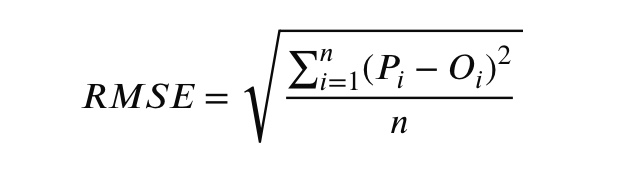

Keterangan:

* y_i = nilai aktual
* hat y_i = nilai prediksi
* n = jumlah data

Semakin kecil nilai RMSE, semakin baik performa model. Karena error dikuadratkan terlebih dahulu, RMSE sangat sensitif terhadap kesalahan prediksi yang besar.

**MAE**

MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi.

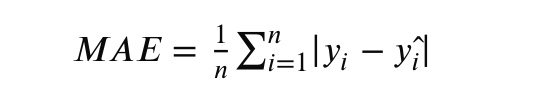

Keterangan:

* y_i = nilai aktual
* hat y_i = nilai prediksi
* n = jumlah data

Semakin kecil nilai MAE, semakin dekat hasil prediksi terhadap nilai aktual. Berbeda dengan RMSE, MAE tidak memberikan penalti tambahan pada error yang besar sehingga lebih mudah diinterpretasikan.

**MAPE**

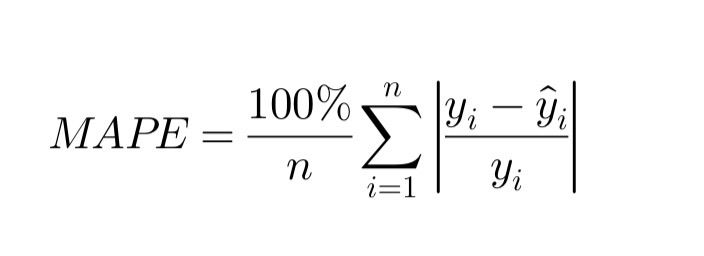

Keterangan:

* y_i = nilai aktual
* hat y_i = nilai prediksi
* n = jumlah data

Semakin kecil nilai MAPE, semakin akurat model dalam melakukan prediksi. Karena dinyatakan dalam persen, MAPE lebih mudah digunakan untuk membandingkan performa model pada dataset yang berbeda.

In [ ]:
hasil = pd.DataFrame({
    'Model': [
        'IBM Baseline',
        'IBM Modified 1',
        'IBM Modified 2',
        'Facebook Baseline',
        'Facebook Modified 1',
        'Facebook Modified 2'
    ],

    'RMSE': [
        rmse,
        rmse_mod_ibm,
        rmse_modified_ibm,
        rmse_fb,
        rmse_mod_fb,
        rmse_modified_fb
    ],

    'MAE': [
        mae,
        mae_mod_ibm,
        mae_modified_ibm,
        mae_fb,
        mae_mod_fb,
        mae_modified_fb
    ],

    'MAPE (%)': [
        mape * 100,
        mape_mod_ibm * 100,
        mape_modified_ibm * 100,
        mape_fb * 100,
        mape_mod_fb * 100,
        mape_modified_fb * 100
    ]
})

hasil = hasil.round({
    'RMSE': 2,
    'MAE': 2,
    'MAPE (%)': 2
})

print(hasil)

                 Model   RMSE    MAE  MAPE (%)
0         IBM Baseline   3.58   2.33      1.80
1       IBM Modified 1   2.71   1.76      1.35
2       IBM Modified 2   5.38   3.95      3.01
3    Facebook Baseline   8.28   7.25      3.75
4  Facebook Modified 1   5.01   4.06      2.16
5  Facebook Modified 2  12.52  10.84      5.73


**IBM Baseline**

Model IBM Baseline menghasilkan RMSE sebesar 3,58, MAE sebesar 2,33, dan MAPE sebesar 1,80%. Nilai MAPE yang rendah menunjukkan bahwa rata-rata kesalahan prediksi hanya sekitar 1,80% dari harga saham aktual. Hasil ini menunjukkan bahwa model baseline sudah mampu menangkap pola pergerakan harga saham IBM dengan cukup baik.

**IBM Modified 1**

Model IBM Modified 1 menghasilkan RMSE sebesar 2,71, MAE sebesar 1,76, dan MAPE sebesar 1,35%. Dibandingkan model baseline, seluruh nilai error mengalami penurunan. Penurunan RMSE sekitar 24%, MAE sekitar 24%, dan MAPE sekitar 25% menunjukkan bahwa modifikasi arsitektur berhasil meningkatkan akurasi prediksi serta kemampuan model dalam mempelajari pola data saham IBM.

**IBM Modified 2**

Model IBM Modified 2 menghasilkan RMSE sebesar 5,38, MAE sebesar 3,95, dan MAPE sebesar 3,01%. Meskipun penambahan Dropout berhasil mengurangi risiko overfitting dan meningkatkan kemampuan generalisasi model, nilai error pada data testing meningkat dibandingkan Modified 1 maupun baseline. Hal ini menunjukkan bahwa regularisasi yang diterapkan membuat model lebih stabil, tetapi mengurangi ketepatan prediksi terhadap data saham IBM.

**Facebook Baseline**

Model Facebook Baseline menghasilkan RMSE sebesar 8,28, MAE sebesar 7,25, dan MAPE sebesar 3,75%. Nilai error yang lebih tinggi dibandingkan model IBM menunjukkan bahwa pola pergerakan harga saham Facebook lebih kompleks untuk dipelajari. Selain itu, hasil evaluasi mengindikasikan bahwa model baseline masih memiliki ruang untuk ditingkatkan melalui modifikasi arsitektur.

**Facebook Modified 1**

Model Facebook Modified 1 menghasilkan RMSE sebesar 5,01, MAE sebesar 4,06, dan MAPE sebesar 2,16%. Dibandingkan model baseline, terjadi penurunan RMSE sekitar 39%, MAE sekitar 44%, dan MAPE sekitar 42%. Hasil ini menunjukkan bahwa penambahan layer LSTM, penggunaan fungsi aktivasi tanh, serta optimizer Adam berhasil meningkatkan kemampuan model dalam mempelajari pola data dan menghasilkan prediksi yang lebih akurat.

**Facebook Modified 2**

Model Facebook Modified 2 menghasilkan RMSE sebesar 12,52, MAE sebesar 10,84, dan MAPE sebesar 5,73%. Walaupun penggunaan Dropout berhasil menurunkan tingkat overfitting yang ditunjukkan oleh gap ratio yang lebih kecil, performa prediksi pada data testing justru mengalami penurunan. Nilai error yang lebih besar dibandingkan Modified 1 menunjukkan bahwa model menjadi terlalu konservatif sehingga kurang mampu mengikuti perubahan harga saham Facebook secara akurat.



**Secara Keseluruhan**

Berdasarkan seluruh hasil pengujian, IBM Modified 1 dan Facebook Modified 1 merupakan model dengan performa terbaik pada masing-masing dataset. Kedua model menghasilkan nilai RMSE, MAE, dan MAPE terendah dibandingkan model baseline maupun Modified 2. Sementara itu, penambahan Dropout pada Modified 2 memang berhasil mengurangi overfitting, tetapi menyebabkan penurunan akurasi prediksi pada data testing. Oleh karena itu, Modified 1 dipilih sebagai model terbaik karena memberikan keseimbangan yang lebih baik antara kemampuan mempelajari pola data dan akurasi prediksi harga saham.